# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [16]:
# At first I created a Card class, then the Deck class, and finally the Player class.
# The card class stores the suit and rank of the cards that are in play
# Then the deck class makes a deck with multiple decks and adds an end card at a random point within the large deck, then draws the cards.
# The player class then stores chips and keeps the players hand - Keeping track of the players hand value and letting the player choose
# if he wants an Ace he potentially has to be a 1 or an 11.

import random


class Card:
    suits = ["Hearts", "Clubs", "Diamonds", "Spades"]
    ranks = ["Ace", "2", "3", "4", "5", "6", "7", "8", "9", "10", "Jack", "Queen", "King"]

    def __init__(self, suit, rank): # Making the cards & labeling which card it is
        self.suit_name = suit
        self.rank_name = rank
        self.endcard = False # Assigning this as false so not all nromal cards are set as end cards.

    def rank(self):
        return self.rank_name

    def card_value(self): # Setting a value to all cards.
        if self.rank_name == "Ace": # This I set for later when the dealer/player comeds into play.
            value = 0
        elif self.rank_name == "Jack" or self.rank_name == "Queen" or self.rank_name == "King":
            value = 10
        else:
            value = int(self.rank_name)

        return value

    def set_endcard(self):
        self.endcard = True

    def is_endcard(self):
        return self.endcard

    def __str__(self): # Looking to see if it's the end card or normal card, and printing it.
        if self.endcard == True:
            which_card = "End Card"
        else:
            which_card = str(self.rank_name) + " of " + str(self.suit_name)

        return which_card


class Deck:
    def __init__(self, num_of_decks = 6): # Making the deck & Assigning 6 decks.
        self.num_of_decks = num_of_decks
        self.cards = []
        self.shuffle_next_hand = False
        self.make_new_deck()

    def make_new_deck(self): # Builds the deck then adds the end card and reshuffles.
        self.cards = []

        for i in range(self.num_of_decks):
            for suit in Card.suits:
                for rank in Card.ranks:
                    self.cards.append(Card(suit, rank))

        endcard = Card("Card", "Plastic")
        endcard.set_endcard()

        place = random.randint(0, len(self.cards) - 1) # Choosing a random spot for the end card.
        self.cards.insert(place, endcard)

        random.shuffle(self.cards)
        self.shuffle_next_hand = False

    def draw_card(self):
        if len(self.cards) == 0:
            self.make_new_deck() # If the deck is empty this will make a new deck

        card = self.cards.pop()

        if card.is_endcard() == True:
            self.shuffle_next_hand = True

            if len(self.cards) == 0:
                self.make_new_deck()

            card = self.cards.pop()

        return card

    def shuffle_if_needed(self):
        if self.shuffle_next_hand == True:
            self.make_new_deck()


class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        self.cards.append(card)

    def clear_hand(self):
        self.cards = []

    def show_hand(self):
        for card in self.cards:
            print(card)

    def hand_value(self, player_choice = False):
        total = 0
        ace_count = 0
    
        for card in self.cards:
            if card.rank() == "Ace":
                ace_count = ace_count + 1
            else:
                total = total + card.card_value()
    
        for i in range(ace_count):
            if player_choice == True and total + 11 <= 21:
                choice = ""
    
                while choice != "1" and choice != "11":
                    choice = input("Since you have an Ace and you would not bust by choosing 11, Would you want the Ace to be a 1 or an 11? Pick 1 or 11.")
    
                    if choice != "1" and choice != "11":
                        print("Please choose 1 or 11.")
    
                if choice == "11":
                    total = total + 11
                else:
                    total = total + 1
    
            else:
                total = total + 11
    
        while total > 21 and ace_count > 0:
            total = total - 10
            ace_count = ace_count - 1
    
        return total

    def is_bust(self):
        if self.hand_value() > 21: # Busting the player if over 21
            busted = True
        else:
            busted = False

        return busted


class Player:
    def __init__(self, chips = 1000): # Assigns the player chips and a hand.
        self.chips_amt = chips
        self.hand = Hand()
        self.current_bet = 0

    def hit(self, deck):
        card = deck.draw_card()
        self.hand.add_card(card)
        return card

    def place_bet(self, amount):
        if amount > self.chips_amt:
            print("You need more chips!")
            self.current_bet = 0
        elif amount <= 0:
            print("Has to be more than 0 and cannot be negative.")
            self.current_bet = 0
        else:
            self.current_bet = amount
            self.chips_amt = self.chips_amt - amount

    def win_bet(self):
        self.chips_amt = self.chips_amt + self.current_bet * 2 # After the player wins, gives them their winnings, then clears the bet.
        self.current_bet = 0

    def lose_bet(self): # Player loses their bet.
        self.current_bet = 0

    def give_bet_back(self): # If the player ties the dealer, it returns their bet back to them, then clears their bet.
        self.chips_amt = self.chips_amt + self.current_bet
        self.current_bet = 0

2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [ ]:
# Here is the skeleton for the UML diagram.
import random


class Card:
    suits = ["Hearts", "Clubs", "Diamonds", "Spades"]
    ranks = ["Ace", "2", "3", "4", "5", "6", "7", "8", "9", "10", "Jack", "Queen", "King"]

    def __init__(self, suit, rank): # Making the cards & labeling which card it is
        self.suit_name = suit
        self.rank_name = rank
        self.endcard = False # Assigning this as false so not all nromal cards are set as end cards.

    def rank(self):
        pass

    def card_value(self): # Setting a value to all cards.
        pass

    def set_endcard(self):
        pass

    def is_endcard(self):
        pass

    def __str__(self): # Looking to see if it's the end card or normal card, and printing it.
        pass


class Deck:
    def __init__(self, num_of_decks = 6): # Making the deck & Assigning 6 decks.
        self.num_of_decks = num_of_decks
        self.cards = []
        self.shuffle_next_hand = False
        self.make_new_deck()

    def make_new_deck(self): # Builds the deck then adds the end card and reshuffles.
        pass

    def draw_card(self):
        pass

    def shuffle_if_needed(self):
        pass


class Hand:
    def __init__(self):
        pass

    def add_card(self, card):
        pass

    def clear_hand(self):
        pass

    def show_hand(self):
        pass

    def hand_value(self, player_choice = False):
        pass

    def is_bust(self):
        pass


class Player:
    def __init__(self, chips = 1000): # Assigns the player chips and a hand.
        self.chips_amt = chips
        self.hand = Hand()
        self.current_bet = 0

    def hit(self, deck):
        pass

    def place_bet(self, amount):
        pass

    def win_bet(self):
        pass

    def lose_bet(self): # Player loses their bet.
        pass

    def give_bet_back(self): # If the player ties the dealer, it returns their bet back to them, then clears their bet.
        pass

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [17]:
# At first I created a Card class, then the Deck class, and finally the Player class.
# The card class stores the suit and rank of the cards that are in play
# Then the deck class makes a deck with multiple decks and adds an end card at a random point within the large deck, then draws the cards.
# The player class then stores chips and keeps the players hand - Keeping track of the players hand value and letting the player choose
# if he wants an Ace he potentially has to be a 1 or an 11.
# Then I make a dealer class, which hides one of the cards in play, and lists his current card shown on the table.
# After that I make a game class to start a round, take a bet, deal the cards & show the table to the house and the player, 
# And allow the player to hit or stand; And at the end of the round, the game compares the players' and dealers total, and finds a winner.

import random


class Card:
    suits = ["Hearts", "Clubs", "Diamonds", "Spades"]
    ranks = ["Ace", "2", "3", "4", "5", "6", "7", "8", "9", "10", "Jack", "Queen", "King"]

    def __init__(self, suit, rank): # Making the cards & labeling which card it is
        self.suit_name = suit
        self.rank_name = rank
        self.endcard = False # Assigning this as false so not all nromal cards are set as end cards.

    def rank(self):
        return self.rank_name

    def card_value(self): # Setting a value to all cards.
        if self.rank_name == "Ace": # This I set for later when the dealer/player comes into play.
            value = 0
        elif self.rank_name == "Jack" or self.rank_name == "Queen" or self.rank_name == "King":
            value = 10
        else:
            value = int(self.rank_name)

        return value

    def set_endcard(self):
        self.endcard = True

    def is_endcard(self):
        return self.endcard

    def __str__(self): # Looking to see if it's the end card or normal card, and printing it.
        if self.endcard == True:
            which_card = "End Card"
        else:
            which_card = str(self.rank_name) + " of " + str(self.suit_name)

        return which_card


class Deck:
    def __init__(self, num_of_decks = 6): # Making the deck & Assigning 6 decks.
        self.num_of_decks = num_of_decks
        self.cards = []
        self.shuffle_next_hand = False
        self.make_new_deck()

    def make_new_deck(self): # Builds the deck then adds the end card and reshuffles.
        self.cards = []

        for i in range(self.num_of_decks):
            for suit in Card.suits:
                for rank in Card.ranks:
                    self.cards.append(Card(suit, rank))

        endcard = Card("Card", "Plastic")
        endcard.set_endcard()

        place = random.randint(0, len(self.cards) - 1) # Choosing a random spot for the end card.
        self.cards.insert(place, endcard)

        random.shuffle(self.cards)
        self.shuffle_next_hand = False

    def draw_card(self):
        if len(self.cards) == 0:
            self.make_new_deck() # If the deck is empty this will make a new deck

        card = self.cards.pop()

        if card.is_endcard() == True:
            self.shuffle_next_hand = True

            if len(self.cards) == 0:
                self.make_new_deck()

            card = self.cards.pop()

        return card

    def shuffle_if_needed(self):
        if self.shuffle_next_hand == True:
            self.make_new_deck()


class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        self.cards.append(card)

    def clear_hand(self):
        self.cards = []

    def show_hand(self):
        for card in self.cards:
            print(card)

    def hand_value(self, player_choice = False):
        total = 0
        ace_count = 0
    
        for card in self.cards:
            if card.rank() == "Ace":
                ace_count = ace_count + 1
            else:
                total = total + card.card_value()
    
        for i in range(ace_count):
            if player_choice == True and total + 11 <= 21:
                choice = ""
    
                while choice != "1" and choice != "11":
                    choice = input("Since you have an Ace and you would not bust by choosing 11, Would you want the Ace to be a 1 or an 11? Pick 1 or 11.")
    
                    if choice != "1" and choice != "11":
                        print("Please choose 1 or 11.")
    
                if choice == "11":
                    total = total + 11
                else:
                    total = total + 1
    
            else:
                total = total + 11
    
        while total > 21 and ace_count > 0:
            total = total - 10
            ace_count = ace_count - 1
    
        return total

    def is_bust(self):
        if self.hand_value() > 21: # Busting the player if over 21
            busted = True
        else:
            busted = False

        return busted


class Player:
    def __init__(self, chips = 1000): # Assigns the player chips and a hand.
        self.chips_amt = chips
        self.hand = Hand()
        self.current_bet = 0

    def hit(self, deck):
        card = deck.draw_card()
        self.hand.add_card(card)
        return card

    def place_bet(self, amount):
        if amount > self.chips_amt:
            print("You need more chips!")
            self.current_bet = 0
        elif amount <= 0:
            print("Has to be more than 0 and cannot be negative.")
            self.current_bet = 0
        else:
            self.current_bet = amount
            self.chips_amt = self.chips_amt - amount

    def win_bet(self):
        self.chips_amt = self.chips_amt + self.current_bet * 2 # After the player wins, gives them their winnings, then clears the bet.
        self.current_bet = 0

    def lose_bet(self): # Player loses their bet.
        self.current_bet = 0

    def give_bet_back(self): # If the player ties the dealer, it returns their bet back to them, then clears their bet.
        self.chips_amt = self.chips_amt + self.current_bet
        self.current_bet = 0


class Dealer:
    def __init__(self): # Gives the dealer a hand.
        self.hand = Hand()

    def hit(self, deck):
        card = deck.draw_card()
        self.hand.add_card(card)
        return card

    def show_dealer_start_hand(self):
        print(self.hand.cards[0])
        print("Hidden Card")

    def house_turn(self, deck, shown_cards):
        while self.hand.hand_value() < 17: # Makes sure the dealer hits on 16 and stops on 17.
            card = self.hit(deck)
            shown_cards.append(card) # Shows the dealer card.

            print(f"Dealer hits and gets a {card}")
            print(f"Dealer total is now: {self.hand.hand_value()}\n")


class Game:
    def __init__(self, num_of_decks = 6):
        self.deck = Deck(num_of_decks)
        self.player = Player()
        self.dealer = Dealer()
        self.shown_cards = []
        self.game_state = "Waiting for a player"

    def add_shown_card(self, card):
        self.shown_cards.append(card)

    def show_shown_cards(self):
        print("Cards shown so far: ")

        for card in self.shown_cards:
            print(card)

    def start_round(self):
        self.deck.shuffle_if_needed()
        self.player.hand.clear_hand()
        self.dealer.hand.clear_hand()
        self.shown_cards = []
        self.game_state = "Game started"

    def take_bets(self):
        self.game_state = "Betting Phase"

        print(f"You have {self.player.chips_amt} chips left.")
        amount = int(input("How many chips would you like to bet? "))

        self.player.place_bet(amount)

    def deal_cards(self):
        self.game_state = "Cards in play"

        for i in range(2):
            card = self.player.hit(self.deck)
            self.add_shown_card(card)

            card = self.dealer.hit(self.deck)

            if i == 0: # Makes sure to only show one of the dealers cards at the start of the game.
                self.add_shown_card(card)

    def current_table(self):
        print("\nThis is the player's hand.")
        self.player.hand.show_hand()

        print("\nThis is the dealers hand.")
        self.dealer.show_dealer_start_hand()

        print()
        self.show_shown_cards()

    def player_turn(self):
        self.game_state = "Player Turn"

        print("\nIt is the player's turn.")
        player_turn = True
        total = 0

        while player_turn == True:
            print("\nThis is your hand:")
            self.player.hand.show_hand()

            total = self.player.hand.hand_value(True)
            print(f"Your hands total is: {total}\n")

            if total > 21:
                print("You bust!")
                player_turn = False
            else:
                choice = input("Would you like to hit or stand?")
                choice = choice.lower()

                if choice == "hit":
                    card = self.player.hit(self.deck)
                    self.add_shown_card(card)
                elif choice == "stand":
                    player_turn = False
                else:
                    print("Choose Hit or Stand.")

        return total

    def dealers_turn(self):
        self.game_state = "Dealers Turn"
        print("\nIt is the dealer's turn.")

        print("Dealer reveals his hidden card.")
        print(self.dealer.hand.cards[1]) # Dealer reveals the hidden card.

        self.add_shown_card(self.dealer.hand.cards[1])
        self.dealer.house_turn(self.deck, self.shown_cards)

    def find_winner(self, player_total): # Shows totals and determines the winner.
        self.game_state = "Game over"

        dealer_total = self.dealer.hand.hand_value()

        print("\nFinal hands:\n")

        print("Player's hand: ")
        self.player.hand.show_hand()
        print(f"Player hand total: {player_total}")

        print("\nDealer hand: ")
        self.dealer.hand.show_hand()
        print(f"Dealer hand total: {dealer_total}\n")

        if player_total > 21:
            print("Dealer win. You lose!")
            self.player.lose_bet()
        elif dealer_total > 21:
            print("Dealer bust! Player wins!")
            self.player.win_bet()
        elif player_total > dealer_total:
            print("Player wins!")
            self.player.win_bet()
        elif player_total < dealer_total:
            print("Dealer win. You lose!")
            self.player.lose_bet()
        else:
            print("Tie! Your bet is now returned.")
            self.player.give_bet_back()

        print(f"\nYou have {self.player.chips_amt} chips remaining.")

    def play_round(self): # Plays out the round.
        in_game = True

        while in_game == True:
            self.start_round()
            self.take_bets()
            self.deal_cards()
            self.current_table()

            player_total = self.player_turn()

            if player_total <= 21:
                self.dealers_turn()

            self.find_winner(player_total)

            choice = input("\nPlay again? (y/n) ")
            choice = choice.lower()

            if choice == "y":
                in_game = True
            elif choice == "n":
                in_game = False


game = Game(1)
game.play_round()

You have 1000 chips left.


How many chips would you like to bet?  100



This is the player's hand.
Queen of Diamonds
4 of Spades

This is the dealers hand.
Queen of Spades
Hidden Card

Cards shown so far: 
Queen of Diamonds
Queen of Spades
4 of Spades

It is the player's turn.

This is your hand:
Queen of Diamonds
4 of Spades
Your hands total is: 14



Would you like to hit or stand? hit



This is your hand:
Queen of Diamonds
4 of Spades
Ace of Clubs
Your hands total is: 15



Would you like to hit or stand? stand



It is the dealer's turn.
Dealer reveals his hidden card.
9 of Hearts

Final hands:

Player's hand: 
Queen of Diamonds
4 of Spades
Ace of Clubs
Player hand total: 15

Dealer hand: 
Queen of Spades
9 of Hearts
Dealer hand total: 19

Dealer win. You lose!

You have 900 chips remaining.



Play again? (y/n)  n


5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [20]:
# At first I created a Card class, then the Deck class, and finally the Player class.
# The card class stores the suit and rank of the cards that are in play
# Then the deck class makes a deck with multiple decks and adds an end card at a random point within the large deck, then draws the cards.
# The player class then stores chips and keeps the players hand - Keeping track of the players hand value and letting the player choose
# if he wants an Ace he potentially has to be a 1 or an 11.
# Then I make a dealer class, which hides one of the cards in play, and lists his current card shown on the table.
# After that I make a game class to start a round, take a bet, deal the cards & show the table to the house and the player, 
# And allow the player to hit or stand; And at the end of the round, the game compares the players' and dealers total, and finds a winner.

import random


class Card:
    suits = ["Hearts", "Clubs", "Diamonds", "Spades"]
    ranks = ["Ace", "2", "3", "4", "5", "6", "7", "8", "9", "10", "Jack", "Queen", "King"]

    def __init__(self, suit, rank): # Making the cards & labeling which card it is
        self.suit_name = suit
        self.rank_name = rank
        self.endcard = False # Assigning this as false so not all nromal cards are set as end cards.

    def rank(self):
        return self.rank_name

    def card_value(self): # Setting a value to all cards.
        if self.rank_name == "Ace": # This I set for later when the dealer/player comes into play.
            value = 0
        elif self.rank_name == "Jack" or self.rank_name == "Queen" or self.rank_name == "King":
            value = 10
        else:
            value = int(self.rank_name)

        return value

    def set_endcard(self):
        self.endcard = True

    def is_endcard(self):
        return self.endcard

    def __str__(self): # Looking to see if it's the end card or normal card, and printing it.
        if self.endcard == True:
            which_card = "End Card"
        else:
            which_card = str(self.rank_name) + " of " + str(self.suit_name)

        return which_card


class Deck:
    def __init__(self, num_of_decks = 6): # Making the deck & Assigning 6 decks.
        self.num_of_decks = num_of_decks
        self.cards = []
        self.shuffle_next_hand = False
        self.make_new_deck()

    def make_new_deck(self): # Builds the deck then adds the end card and reshuffles.
        self.cards = []

        for i in range(self.num_of_decks):
            for suit in Card.suits:
                for rank in Card.ranks:
                    self.cards.append(Card(suit, rank))

        endcard = Card("Card", "Plastic")
        endcard.set_endcard()

        place = random.randint(0, len(self.cards) - 1) # Choosing a random spot for the end card.
        self.cards.insert(place, endcard)

        random.shuffle(self.cards)
        self.shuffle_next_hand = False

    def draw_card(self):
        if len(self.cards) == 0:
            self.make_new_deck() # If the deck is empty this will make a new deck

        card = self.cards.pop()

        if card.is_endcard() == True:
            self.shuffle_next_hand = True

            if len(self.cards) == 0:
                self.make_new_deck()

            card = self.cards.pop()

        return card

    def shuffle_if_needed(self):
        if self.shuffle_next_hand == True:
            self.make_new_deck()


class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        self.cards.append(card)

    def clear_hand(self):
        self.cards = []

    def show_hand(self):
        for card in self.cards:
            print(card)

    def hand_value(self, player_choice = False):
        total = 0
        ace_count = 0
    
        for card in self.cards:
            if card.rank() == "Ace":
                ace_count = ace_count + 1
            else:
                total = total + card.card_value()
    
        for i in range(ace_count):
            if player_choice == True and total + 11 <= 21:
                choice = ""
    
                while choice != "1" and choice != "11":
                    choice = input("Since you have an Ace and you would not bust by choosing 11, Would you want the Ace to be a 1 or an 11? Pick 1 or 11.")
    
                    if choice != "1" and choice != "11":
                        print("Please choose 1 or 11.")
    
                if choice == "11":
                    total = total + 11
                else:
                    total = total + 1
    
            else:
                total = total + 11
    
        while total > 21 and ace_count > 0:
            total = total - 10
            ace_count = ace_count - 1
    
        return total

    def is_bust(self):
        if self.hand_value() > 21: # Busting the player if over 21
            busted = True
        else:
            busted = False

        return busted


class Player:
    def __init__(self, chips = 1000): # Assigns the player chips and a hand.
        self.chips_amt = chips
        self.hand = Hand()
        self.current_bet = 0

    def hit(self, deck):
        card = deck.draw_card()
        self.hand.add_card(card)
        return card

    def place_bet(self, amount):
        if amount > self.chips_amt:
            print("You need more chips!")
            self.current_bet = 0
        elif amount <= 0:
            print("Has to be more than 0 and cannot be negative.")
            self.current_bet = 0
        else:
            self.current_bet = amount
            self.chips_amt = self.chips_amt - amount

    def win_bet(self):
        self.chips_amt = self.chips_amt + self.current_bet * 2 # After the player wins, gives them their winnings, then clears the bet.
        self.current_bet = 0

    def lose_bet(self): # Player loses their bet.
        self.current_bet = 0

    def give_bet_back(self): # If the player ties the dealer, it returns their bet back to them, then clears their bet.
        self.chips_amt = self.chips_amt + self.current_bet
        self.current_bet = 0


class Dealer:
    def __init__(self): # Gives the dealer a hand.
        self.hand = Hand()

    def hit(self, deck):
        card = deck.draw_card()
        self.hand.add_card(card)
        return card

    def show_dealer_start_hand(self):
        print(self.hand.cards[0])
        print("Hidden Card")

    def house_turn(self, deck, shown_cards):
        while self.hand.hand_value() < 17: # Makes sure the dealer hits on 16 and stops on 17.
            card = self.hit(deck)
            shown_cards.append(card) # Shows the dealer card.

            print(f"Dealer hits and gets a {card}")
            print(f"Dealer total is now: {self.hand.hand_value()}\n")


class Game:
    def __init__(self, num_of_decks = 6):
        self.deck = Deck(num_of_decks)
        self.player = Player()
        self.dealer = Dealer()
        self.shown_cards = []
        self.game_state = "Waiting for a player"

    def add_shown_card(self, card):
        self.shown_cards.append(card)

    def show_shown_cards(self):
        print("Cards shown so far: ")

        for card in self.shown_cards:
            print(card)

    def start_round(self):
        self.deck.shuffle_if_needed()
        self.player.hand.clear_hand()
        self.dealer.hand.clear_hand()
        self.shown_cards = []
        self.game_state = "Game started"

    def take_bets(self):
        self.game_state = "Betting Phase"

        print(f"You have {self.player.chips_amt} chips left.")
        amount = int(input("How many chips would you like to bet? "))

        self.player.place_bet(amount)

    def deal_cards(self):
        self.game_state = "Cards in play"

        for i in range(2):
            card = self.player.hit(self.deck)
            self.add_shown_card(card)

            card = self.dealer.hit(self.deck)

            if i == 0: # Makes sure to only show one of the dealers cards at the start of the game.
                self.add_shown_card(card)

    def current_table(self):
        print("\nThis is the player's hand.")
        self.player.hand.show_hand()

        print("\nThis is the dealers hand.")
        self.dealer.show_dealer_start_hand()

        print()
        self.show_shown_cards()

    def player_turn(self):
        self.game_state = "Player Turn"

        print("\nIt is the player's turn.")
        player_turn = True
        total = 0

        while player_turn == True:
            print("\nThis is your hand:")
            self.player.hand.show_hand()

            total = self.player.hand.hand_value(True)
            print(f"Your hands total is: {total}\n")

            if total > 21:
                print("You bust!")
                player_turn = False
            else:
                choice = input("Would you like to hit or stand?")
                choice = choice.lower()

                if choice == "hit":
                    card = self.player.hit(self.deck)
                    self.add_shown_card(card)
                elif choice == "stand":
                    player_turn = False
                else:
                    print("Choose Hit or Stand.")

        return total

    def dealers_turn(self):
        self.game_state = "Dealers Turn"
        print("\nIt is the dealer's turn.")

        print("Dealer reveals his hidden card.")
        print(self.dealer.hand.cards[1]) # Dealer reveals the hidden card.

        self.add_shown_card(self.dealer.hand.cards[1])
        self.dealer.house_turn(self.deck, self.shown_cards)

    def find_winner(self, player_total): # Shows totals and determines the winner.
        self.game_state = "Game over"

        dealer_total = self.dealer.hand.hand_value()

        print("\nFinal hands:\n")

        print("Player's hand: ")
        self.player.hand.show_hand()
        print(f"Player hand total: {player_total}")

        print("\nDealer hand: ")
        self.dealer.hand.show_hand()
        print(f"Dealer hand total: {dealer_total}\n")

        if player_total > 21:
            print("Dealer win. You lose!")
            self.player.lose_bet()
        elif dealer_total > 21:
            print("Dealer bust! Player wins!")
            self.player.win_bet()
        elif player_total > dealer_total:
            print("Player wins!")
            self.player.win_bet()
        elif player_total < dealer_total:
            print("Dealer win. You lose!")
            self.player.lose_bet()
        else:
            print("Tie! Your bet is now returned.")
            self.player.give_bet_back()

        print(f"\nYou have {self.player.chips_amt} chips remaining.")

    def play_round(self): # Plays out the round.
        in_game = True

        while in_game == True:
            self.start_round()
            self.take_bets()
            self.deal_cards()
            self.current_table()

            player_total = self.player_turn()

            if player_total <= 21:
                self.dealers_turn()

            self.find_winner(player_total)

            choice = input("\nPlay again? (y/n) ")
            choice = choice.lower()

            if choice == "y":
                in_game = True
            elif choice == "n":
                in_game = False

    def test_player_turn(self):
        player_total = self.player.hand.hand_value(False)
    
        while player_total < 17:
            card = self.player.hit(self.deck)
            self.add_shown_card(card)
    
            print(f"Player hits and gets a {card}")
    
            player_total = self.player.hand.hand_value(False)
            
            print(f"Player total is now: {player_total}\n")
    
        if player_total >= 17 and player_total <= 21:
            print("Player stands.")
    
        if player_total > 21:
            print("Player loses! - They bust!")
    
        return player_total
    
    def test_round(self):
        self.start_round()
    
        self.player.place_bet(100)
    
        self.deal_cards()
        self.current_table()
    
        player_total = self.test_player_turn()
    
        if player_total <= 21:
            self.dealers_turn()
    
        self.find_winner(player_total)

game = Game(1)

for game_number in range(1, 8): # Loops the games until it's ran multiple games against dealers.
    print(f"\nGame Number: {game_number}\n")

    game.test_round()

    print("\nDealer hand:")
    game.dealer.hand.show_hand()
    print(f"Dealer total: {game.dealer.hand.hand_value()}")

    print("\nPlayer hand:")
    game.player.hand.show_hand()
    print(f"Player total: {game.player.hand.hand_value()}")

    print(f"\nPlayer chips: {game.player.chips_amt}")
    print("\nEnd of game number", game_number)


Game Number: 1


This is the player's hand.
King of Clubs
5 of Clubs

This is the dealers hand.
7 of Clubs
Hidden Card

Cards shown so far: 
King of Clubs
7 of Clubs
5 of Clubs
Player hits and gets a 7 of Spades
Player total is now: 22

Player loses! - They bust!

Final hands:

Player's hand: 
King of Clubs
5 of Clubs
7 of Spades
Player hand total: 22

Dealer hand: 
7 of Clubs
9 of Spades
Dealer hand total: 16

Dealer win. You lose!

You have 900 chips remaining.

Dealer hand:
7 of Clubs
9 of Spades
Dealer total: 16

Player hand:
King of Clubs
5 of Clubs
7 of Spades
Player total: 22

Player chips: 900

End of game number 1

Game Number: 2


This is the player's hand.
3 of Hearts
2 of Diamonds

This is the dealers hand.
Queen of Spades
Hidden Card

Cards shown so far: 
3 of Hearts
Queen of Spades
2 of Diamonds
Player hits and gets a Jack of Diamonds
Player total is now: 15

Player hits and gets a 4 of Spades
Player total is now: 19

Player stands.

It is the dealer's turn.
Dealer revea

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [41]:
# At first I created a Card class, then the Deck class, and finally the Player class.
# The card class stores the suit and rank of the cards that are in play
# Then the deck class makes a deck with multiple decks and adds an end card at a random point within the large deck, then draws the cards.
# The player class then stores chips and keeps the players hand - Keeping track of the players hand value and letting the player choose
# if he wants an Ace he potentially has to be a 1 or an 11.
# Then I make a dealer class, which hides one of the cards in play, and lists his current card shown on the table.
# After that I make a game class to start a round, take a bet, deal the cards & show the table to the house and the player, 
# And allow the player to hit or stand; And at the end of the round, the game compares the players' and dealers total, and finds a winner.

import random


class Card:
    suits = ["Hearts", "Clubs", "Diamonds", "Spades"]
    ranks = ["Ace", "2", "3", "4", "5", "6", "7", "8", "9", "10", "Jack", "Queen", "King"]

    def __init__(self, suit, rank): # Making the cards & labeling which card it is
        self.suit_name = suit
        self.rank_name = rank
        self.endcard = False # Assigning this as false so not all nromal cards are set as end cards.

    def rank(self):
        return self.rank_name

    def card_value(self): # Setting a value to all cards.
        if self.rank_name == "Ace": # This I set for later when the dealer/player comes into play.
            value = 0
        elif self.rank_name == "Jack" or self.rank_name == "Queen" or self.rank_name == "King":
            value = 10
        else:
            value = int(self.rank_name)

        return value

    def set_endcard(self):
        self.endcard = True

    def is_endcard(self):
        return self.endcard

    def __str__(self): # Looking to see if it's the end card or normal card, and printing it.
        if self.endcard == True:
            which_card = "End Card"
        else:
            which_card = str(self.rank_name) + " of " + str(self.suit_name)

        return which_card


class Deck:
    def __init__(self, num_of_decks = 6): # Making the deck & Assigning 6 decks.
        self.num_of_decks = num_of_decks
        self.cards = []
        self.shuffle_next_hand = False
        self.make_new_deck()

    def make_new_deck(self): # Builds the deck then adds the end card and reshuffles.
        self.cards = []

        for i in range(self.num_of_decks):
            for suit in Card.suits:
                for rank in Card.ranks:
                    self.cards.append(Card(suit, rank))

        endcard = Card("Card", "Plastic")
        endcard.set_endcard()

        place = random.randint(0, len(self.cards) - 1) # Choosing a random spot for the end card.
        self.cards.insert(place, endcard)

        random.shuffle(self.cards)
        self.shuffle_next_hand = False

    def draw_card(self):
        if len(self.cards) == 0:
            self.make_new_deck() # If the deck is empty this will make a new deck

        card = self.cards.pop()

        if card.is_endcard() == True:
            self.shuffle_next_hand = True

            if len(self.cards) == 0:
                self.make_new_deck()

            card = self.cards.pop()

        return card

    def shuffle_if_needed(self):
        if self.shuffle_next_hand == True:
            self.make_new_deck()


class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        self.cards.append(card)

    def clear_hand(self):
        self.cards = []

    def show_hand(self):
        for card in self.cards:
            print(card)

    def hand_value(self, player_choice = False):
        total = 0
        ace_count = 0
    
        for card in self.cards:
            if card.rank() == "Ace":
                ace_count = ace_count + 1
            else:
                total = total + card.card_value()
    
        for i in range(ace_count):
            if player_choice == True and total + 11 <= 21:
                choice = ""
    
                while choice != "1" and choice != "11":
                    choice = input("Since you have an Ace and you would not bust by choosing 11, Would you want the Ace to be a 1 or an 11? Pick 1 or 11.")
    
                    if choice != "1" and choice != "11":
                        print("Please choose 1 or 11.")
    
                if choice == "11":
                    total = total + 11
                else:
                    total = total + 1
    
            else:
                total = total + 11
    
        while total > 21 and ace_count > 0:
            total = total - 10
            ace_count = ace_count - 1
    
        return total

    def is_bust(self):
        if self.hand_value() > 21: # Busting the player if over 21
            busted = True
        else:
            busted = False

        return busted


class Player:
    def __init__(self, chips = 1000): # Assigns the player chips and a hand.
        self.chips_amt = chips
        self.hand = Hand()
        self.current_bet = 0

    def hit(self, deck):
        card = deck.draw_card()
        self.hand.add_card(card)
        return card

    def place_bet(self, amount):
        if amount > self.chips_amt:
            print("You need more chips!")
            self.current_bet = 0
        elif amount <= 0:
            print("Has to be more than 0 and cannot be negative.")
            self.current_bet = 0
        else:
            self.current_bet = amount
            self.chips_amt = self.chips_amt - amount

    def win_bet(self):
        self.chips_amt = self.chips_amt + self.current_bet * 2 # After the player wins, gives them their winnings, then clears the bet.
        self.current_bet = 0

    def lose_bet(self): # Player loses their bet.
        self.current_bet = 0

    def give_bet_back(self): # If the player ties the dealer, it returns their bet back to them, then clears their bet.
        self.chips_amt = self.chips_amt + self.current_bet
        self.current_bet = 0

class CardCounter(Player):
    def __init__(self, chips = 1000, advantage = 0):
        super().__init__(chips)
        self.current_advantage = advantage
        self.count = 0

    def card_count_total(self, card): # Gives each card it's count value
        if card.rank() == "2" or card.rank() == "3" or card.rank() == "4" or card.rank() == "5" or card.rank() == "6":
            value = 1
        elif card.rank() == "7" or card.rank() == "8" or card.rank() == "9":
            value = 0
        else:
            value = -1

        return value

    def update_count(self, shown_cards):
        self.count = 0 # Restarts the count when new session, and counts each one seen.

        for card in shown_cards:
            self.count = self.count + self.card_count_total(card)

    def make_advantaged_move(self, shown_cards):
        self.update_count(shown_cards)

        if self.count <= self.current_advantage: # Low count makes the player hit
            advantage_move = "hit"
        else:
            advantage_move = "stand" # High count makes the player stand

        return advantage_move

class Dealer:
    def __init__(self): # Gives the dealer a hand.
        self.hand = Hand()

    def hit(self, deck):
        card = deck.draw_card()
        self.hand.add_card(card)
        return card

    def show_dealer_start_hand(self):
        print(self.hand.cards[0])
        print("Hidden Card")

    def house_turn(self, deck):
        new_cards = []

        while self.hand.hand_value() < 17: # Makes sure the dealer hits on 16 and stops on 17.
            card = self.hit(deck)
            new_cards.append(card) # Shows the dealer card.


        return new_cards


class Game:
    def __init__(self, num_of_decks = 6):
        self.deck = Deck(num_of_decks)
        self.player = CardCounter(1000, 0)
        self.dealer = Dealer()
        self.shown_cards = []
        self.all_seen_cards = []
        self.game_state = "Waiting for a player"

    def add_shown_card(self, card):
        self.shown_cards.append(card)
        self.all_seen_cards.append(card) # Lets the card counter remember cards across the game.

    def show_shown_cards(self):
        print("Cards shown so far: ")

        for card in self.shown_cards:
            print(card)

    def start_round(self):
        if self.deck.shuffle_next_hand == True:
            self.deck.shuffle_if_needed()
            self.all_seen_cards = [] # If the deck gets shuffled the count resets

        self.player.hand.clear_hand()
        self.dealer.hand.clear_hand()
        self.shown_cards = []
        self.game_state = "Game started"

    def take_bets(self):
        self.game_state = "Betting Phase"

        print(f"You have {self.player.chips_amt} chips left.")
        amount = int(input("How many chips would you like to bet? "))

        self.player.place_bet(amount)

    def deal_cards(self):
        self.game_state = "Cards in play"

        for i in range(2):
            card = self.player.hit(self.deck)
            self.add_shown_card(card)

            card = self.dealer.hit(self.deck)

            if i == 0: # Makes sure to only show one of the dealers cards at the start of the game.
                self.add_shown_card(card)

    def current_table(self):
        print("\nThis is the player's hand.")
        self.player.hand.show_hand()

        print("\nThis is the dealers hand.")
        self.dealer.show_dealer_start_hand()

        print()
        self.show_shown_cards()

    def player_turn(self):
        self.game_state = "Player Turn"

        print("\nIt is the player's turn.")
        player_turn = True
        total = 0

        while player_turn == True:
            print("\nThis is your hand:")
            self.player.hand.show_hand()

            total = self.player.hand.hand_value(True)
            print(f"Your hands total is: {total}\n")

            if total > 21:
                print("You bust!")
                player_turn = False
            else:
                choice = input("Would you like to hit or stand?")
                choice = choice.lower()

                if choice == "hit":
                    card = self.player.hit(self.deck)
                    self.add_shown_card(card)
                elif choice == "stand":
                    player_turn = False
                else:
                    print("Choose Hit or Stand.")

        return total

    def card_counter_turn(self):
        player_total = self.player.hand.hand_value(False) # AI Chooses the ace value

        while player_total <= 21 and self.player.make_advantaged_move(self.all_seen_cards) == "hit": # If advantage is high, hit.
            print(f"Current card count is: {self.player.count}") 
            print("Card counter chooses to hit.")

            card = self.player.hit(self.deck)
            self.add_shown_card(card)

            print(f"Player hits and gets a {card}")

            player_total = self.player.hand.hand_value(False)
            print(f"Player total is now: {player_total}\n")

        if player_total <= 21:
            self.player.update_count(self.all_seen_cards) 
            print(f"Current card count is: {self.player.count}")
            print("Card counter chooses to stand.")

        if player_total > 21:
            print("Player loses! - They bust!")

        return player_total

    def dealers_turn(self):
        self.game_state = "Dealers Turn"
        print("\nIt is the dealer's turn.")

        print("Dealer reveals his hidden card.")
        print(self.dealer.hand.cards[1]) # Dealer reveals the hidden card.

        self.add_shown_card(self.dealer.hand.cards[1])

        dealer_cards = self.dealer.house_turn(self.deck)

        for card in dealer_cards:
            self.add_shown_card(card) # The dealer's hit cards also have to be counted or it'll make an inaccurate count

    def find_winner(self, player_total): # Shows totals and determines the winner.
        self.game_state = "Game over"

        dealer_total = self.dealer.hand.hand_value()

        print("\nFinal hands:\n")

        print("Player's hand: ")
        self.player.hand.show_hand()
        print(f"Player hand total: {player_total}")

        print("\nDealer hand: ")
        self.dealer.hand.show_hand()
        print(f"Dealer hand total: {dealer_total}\n")

        if player_total > 21:
            print("Dealer win. You lose!")
            self.player.lose_bet()
        elif dealer_total > 21:
            print("Dealer bust! Player wins!")
            self.player.win_bet()
        elif player_total > dealer_total:
            print("Player wins!")
            self.player.win_bet()
        elif player_total < dealer_total:
            print("Dealer win. You lose!")
            self.player.lose_bet()
        else:
            print("Tie! Your bet is now returned.")
            self.player.give_bet_back()

        print(f"\nYou have {self.player.chips_amt} chips remaining.")

    def play_round(self): # Plays out the round.
        in_game = True

        while in_game == True:
            self.start_round()
            self.take_bets()
            self.deal_cards()
            self.current_table()

            player_total = self.player_turn()

            if player_total <= 21:
                self.dealers_turn()

            self.find_winner(player_total)

            choice = input("\nPlay again? (y/n) ")
            choice = choice.lower()

            if choice == "y":
                in_game = True
            elif choice == "n":
                in_game = False

    def test_round(self):
        self.start_round()

        self.player.place_bet(100)

        self.deal_cards()
        self.current_table()

        player_total = self.card_counter_turn()

        if player_total <= 21:
            self.dealers_turn()

        self.find_winner(player_total)

game = Game(1)

for game_number in range(1, 8): # Loops the games until it's ran multiple games against dealers.
    print(f"\nGame Number: {game_number}\n")

    game.test_round()

    print("\nDealer hand:")
    game.dealer.hand.show_hand()
    print(f"Dealer total: {game.dealer.hand.hand_value()}")

    print("\nPlayer hand:")
    game.player.hand.show_hand()
    print(f"Player total: {game.player.hand.hand_value()}")

    print(f"\nPlayer chips: {game.player.chips_amt}")
    print("\nEnd of game number", game_number)


Game Number: 1


This is the player's hand.
2 of Clubs
9 of Clubs

This is the dealers hand.
Jack of Clubs
Hidden Card

Cards shown so far: 
2 of Clubs
Jack of Clubs
9 of Clubs
Current card count is: 0
Card counter chooses to hit.
Player hits and gets a 7 of Clubs
Player total is now: 18

Current card count is: 0
Card counter chooses to hit.
Player hits and gets a King of Diamonds
Player total is now: 28

Player loses! - They bust!

Final hands:

Player's hand: 
2 of Clubs
9 of Clubs
7 of Clubs
King of Diamonds
Player hand total: 28

Dealer hand: 
Jack of Clubs
7 of Hearts
Dealer hand total: 17

Dealer win. You lose!

You have 900 chips remaining.

Dealer hand:
Jack of Clubs
7 of Hearts
Dealer total: 17

Player hand:
2 of Clubs
9 of Clubs
7 of Clubs
King of Diamonds
Player total: 28

Player chips: 900

End of game number 1

Game Number: 2


This is the player's hand.
King of Hearts
Jack of Spades

This is the dealers hand.
4 of Clubs
Hidden Card

Cards shown so far: 
King of Hearts
4 

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [43]:
# At first I created a Card class, then the Deck class, and finally the Player class.
# The card class stores the suit and rank of the cards that are in play
# Then the deck class makes a deck with multiple decks and adds an end card at a random point within the large deck, then draws the cards.
# The player class then stores chips and keeps the players hand - Keeping track of the players hand value and letting the player choose
# if he wants an Ace he potentially has to be a 1 or an 11.
# Then I make a dealer class, which hides one of the cards in play, and lists his current card shown on the table.
# After that I make a game class to start a round, take a bet, deal the cards & show the table to the house and the player, 
# And allow the player to hit or stand; And at the end of the round, the game compares the players' and dealers total, and finds a winner.

import random


class Card:
    suits = ["Hearts", "Clubs", "Diamonds", "Spades"]
    ranks = ["Ace", "2", "3", "4", "5", "6", "7", "8", "9", "10", "Jack", "Queen", "King"]

    def __init__(self, suit, rank): # Making the cards & labeling which card it is
        self.suit_name = suit
        self.rank_name = rank
        self.endcard = False # Assigning this as false so not all nromal cards are set as end cards.

    def rank(self):
        return self.rank_name

    def card_value(self): # Setting a value to all cards.
        if self.rank_name == "Ace": # This I set for later when the dealer/player comes into play.
            value = 0
        elif self.rank_name == "Jack" or self.rank_name == "Queen" or self.rank_name == "King":
            value = 10
        else:
            value = int(self.rank_name)

        return value

    def set_endcard(self):
        self.endcard = True

    def is_endcard(self):
        return self.endcard

    def __str__(self): # Looking to see if it's the end card or normal card, and printing it.
        if self.endcard == True:
            which_card = "End Card"
        else:
            which_card = str(self.rank_name) + " of " + str(self.suit_name)

        return which_card


class Deck:
    def __init__(self, num_of_decks = 6): # Making the deck & Assigning 6 decks.
        self.num_of_decks = num_of_decks
        self.cards = []
        self.shuffle_next_hand = False
        self.make_new_deck()

    def make_new_deck(self): # Builds the deck then adds the end card and reshuffles.
        self.cards = []

        for i in range(self.num_of_decks):
            for suit in Card.suits:
                for rank in Card.ranks:
                    self.cards.append(Card(suit, rank))

        endcard = Card("Card", "Plastic")
        endcard.set_endcard()

        place = random.randint(0, len(self.cards) - 1) # Choosing a random spot for the end card.
        self.cards.insert(place, endcard)

        random.shuffle(self.cards)
        self.shuffle_next_hand = False

    def draw_card(self):
        if len(self.cards) == 0:
            self.make_new_deck() # If the deck is empty this will make a new deck

        card = self.cards.pop()

        if card.is_endcard() == True:
            self.shuffle_next_hand = True

            if len(self.cards) == 0:
                self.make_new_deck()

            card = self.cards.pop()

        return card

    def shuffle_if_needed(self):
        if self.shuffle_next_hand == True:
            self.make_new_deck()


class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        self.cards.append(card)

    def clear_hand(self):
        self.cards = []

    def show_hand(self):
        for card in self.cards:
            print(card)

    def hand_value(self, player_choice = False):
        total = 0
        ace_count = 0
    
        for card in self.cards:
            if card.rank() == "Ace":
                ace_count = ace_count + 1
            else:
                total = total + card.card_value()
    
        for i in range(ace_count):
            if player_choice == True and total + 11 <= 21:
                choice = ""
    
                while choice != "1" and choice != "11":
                    choice = input("Since you have an Ace and you would not bust by choosing 11, Would you want the Ace to be a 1 or an 11? Pick 1 or 11.")
    
                    if choice != "1" and choice != "11":
                        print("Please choose 1 or 11.")
    
                if choice == "11":
                    total = total + 11
                else:
                    total = total + 1
    
            else:
                total = total + 11
    
        while total > 21 and ace_count > 0:
            total = total - 10
            ace_count = ace_count - 1
    
        return total

    def is_bust(self):
        if self.hand_value() > 21: # Busting the player if over 21
            busted = True
        else:
            busted = False

        return busted


class Player:
    def __init__(self, chips = 1000): # Assigns the player chips and a hand.
        self.chips_amt = chips
        self.hand = Hand()
        self.current_bet = 0

    def hit(self, deck):
        card = deck.draw_card()
        self.hand.add_card(card)
        return card

    def place_bet(self, amount):
        if amount > self.chips_amt:
            print("You need more chips!")
            self.current_bet = 0
        elif amount <= 0:
            print("Has to be more than 0 and cannot be negative.")
            self.current_bet = 0
        else:
            self.current_bet = amount
            self.last_bet = amount
            self.chips_amt = self.chips_amt - amount

    def win_bet(self):
        self.chips_amt = self.chips_amt + self.current_bet * 2 # After the player wins, gives them their winnings, then clears the bet.
        self.current_bet = 0

    def lose_bet(self): # Player loses their bet.
        self.current_bet = 0

    def give_bet_back(self): # If the player ties the dealer, it returns their bet back to them, then clears their bet.
        self.chips_amt = self.chips_amt + self.current_bet
        self.current_bet = 0

class CardCounter(Player):
    def __init__(self, chips = 1000, advantage = 0):
        super().__init__(chips)
        self.current_advantage = advantage
        self.count = 0

    def card_count_total(self, card): # Gives each card it's count value
        if card.rank() == "2" or card.rank() == "3" or card.rank() == "4" or card.rank() == "5" or card.rank() == "6":
            value = 1
        elif card.rank() == "7" or card.rank() == "8" or card.rank() == "9":
            value = 0
        else:
            value = -1

        return value

    def update_count(self, shown_cards):
        self.count = 0 # Restarts the count when new session, and counts each one seen.

        for card in shown_cards:
            self.count = self.count + self.card_count_total(card)

    def make_advantaged_move(self, shown_cards):
        self.update_count(shown_cards)
    
        total = self.hand.hand_value(False)
    
        if total < 12:
            advantage_move = "hit"
        elif total >= 17:
            advantage_move = "stand"
        else:
            if self.count >= self.current_advantage:
                advantage_move = "stand" # High count makes the player stand
            else:
                advantage_move = "hit" # Low count makes the player hit
    
        return advantage_move

    def make_bet_amount(self):
        if self.count >= 10:
            bet = 50
        elif self.count >= 5:
            bet = 25
        else:
            bet = 10
    
        if bet > self.chips_amt:
            bet = self.chips_amt
    
        return bet

class OtherPlayers(Player): # Adds in the other players similar to the dealer.
    def make_move(self):
        total = self.hand.hand_value(False)

        if total < 17:
            move = "hit"
        else:
            move = "stand"

        return move

class Dealer:
    def __init__(self): # Gives the dealer a hand.
        self.hand = Hand()

    def hit(self, deck):
        card = deck.draw_card()
        self.hand.add_card(card)
        return card

    def show_dealer_start_hand(self):
        print(self.hand.cards[0])
        print("Hidden Card")

    def house_turn(self, deck):
        new_cards = []
    
        while self.hand.hand_value() < 17: # Makes sure the dealer hits on 16 and stops on 17.
            card = self.hit(deck)
            new_cards.append(card) # Shows the dealer card.
    
        return new_cards


class Game:
    def __init__(self, num_of_decks = 6, quiet = True):
        self.deck = Deck(num_of_decks)
        self.card_counter = CardCounter(1000, 0)
        self.players = [self.card_counter, OtherPlayers(1000), OtherPlayers(1000), OtherPlayers(1000)]
        self.dealer = Dealer()
        self.shown_cards = []
        self.all_seen_cards = []
        self.game_state = "Waiting for a player"
        self.quiet = quiet
        self.last_bet = 0

    def add_shown_card(self, card):
        self.shown_cards.append(card)
        self.all_seen_cards.append(card) # Lets the card counter remember cards across the game.

    def show_shown_cards(self):
        print("Cards shown so far: ")

        for card in self.shown_cards:
            print(card)

    def start_round(self):
        if self.deck.shuffle_next_hand == True:
            self.deck.shuffle_if_needed()
            self.all_seen_cards = [] # If the deck gets shuffled the count resets
    
        for player in self.players:
            player.hand.clear_hand()
    
        self.dealer.hand.clear_hand()
        self.shown_cards = []
        self.game_state = "Game started"

    def take_bets(self):
        self.game_state = "Betting Phase"

        print(f"You have {self.player.chips_amt} chips left.")
        amount = int(input("How many chips would you like to bet? "))

        self.player.place_bet(amount)

    def test_bets(self):
        self.card_counter.update_count(self.all_seen_cards)
    
        card_counter_bet = self.card_counter.make_bet_amount()
        self.card_counter.place_bet(card_counter_bet)
    
        for player in self.players[1:]:
            if player.chips_amt >= 100:
                player.place_bet(100)

    def deal_cards(self):
        self.game_state = "Cards in play"
    
        for i in range(2):
            for player in self.players:
                card = player.hit(self.deck)
                self.add_shown_card(card)
    
            card = self.dealer.hit(self.deck)
            self.add_shown_card(card)

    def card_counter_turn(self):
        player_total = self.card_counter.hand.hand_value(False)
    
        while player_total <= 21 and self.card_counter.make_advantaged_move(self.all_seen_cards) == "hit":
            card = self.card_counter.hit(self.deck)
            self.add_shown_card(card)
    
            player_total = self.card_counter.hand.hand_value(False)
    
        self.card_counter.update_count(self.all_seen_cards)
    
        return player_total

    def other_players_turn(self, player):
        player_total = player.hand.hand_value(False)
    
        while player_total < 17:
            card = player.hit(self.deck)
            self.add_shown_card(card)
    
            player_total = player.hand.hand_value(False)
    
        return player_total

    def current_table(self):
        print("\nThis is the player's hand.")
        self.player.hand.show_hand()

        print("\nThis is the dealers hand.")
        self.dealer.show_dealer_start_hand()

        print()
        self.show_shown_cards()

    def player_turn(self):
        self.game_state = "Player Turn"

        print("\nIt is the player's turn.")
        player_turn = True
        total = 0

        while player_turn == True:
            print("\nThis is your hand:")
            self.player.hand.show_hand()

            total = self.player.hand.hand_value(True)
            print(f"Your hands total is: {total}\n")

            if total > 21:
                print("You bust!")
                player_turn = False
            else:
                choice = input("Would you like to hit or stand?")
                choice = choice.lower()

                if choice == "hit":
                    card = self.player.hit(self.deck)
                    self.add_shown_card(card)
                elif choice == "stand":
                    player_turn = False
                else:
                    print("Choose Hit or Stand.")

        return total

    def dealers_turn(self):
        self.game_state = "Dealers Turn"
    
        dealer_cards = self.dealer.house_turn(self.deck) 
    
        for card in dealer_cards:
            self.add_shown_card(card)

    def find_winner(self, player_totals):
        self.game_state = "Game over"
    
        dealer_total = self.dealer.hand.hand_value()
        results = []
    
        for i in range(len(self.players)):
            player = self.players[i]
            player_total = player_totals[i]
    
            if i == 0:
                player_name = "Card Counter"
            else:
                player_name = "Player " + str(i + 1)
    
            if player_total > 21:
                player.lose_bet()
                results.append(f"{player_name} busted and lost.")
            elif dealer_total > 21:
                player.win_bet()
                results.append(f"{player_name} won because dealer busted.")
            elif player_total > dealer_total:
                player.win_bet()
                results.append(f"{player_name} won.")
            elif player_total < dealer_total:
                player.lose_bet()
                results.append(f"{player_name} lost.")
            else:
                player.give_bet_back()
                results.append(f"{player_name} tied, so the bet was returned.")
    
        return results

    def play_round(self): # Plays out the round.
        in_game = True

        while in_game == True:
            self.start_round()
            self.take_bets()
            self.deal_cards()
            self.current_table()

            player_total = self.player_turn()

            if player_total <= 21:
                self.dealers_turn()

            self.find_winner(player_total)

            choice = input("\nPlay again? (y/n) ")
            choice = choice.lower()

            if choice == "y":
                in_game = True
            elif choice == "n":
                in_game = False

    def test_player_turn(self):
        player_total = self.player.hand.hand_value(False) # AI Chooses the ace value
    
        while player_total <= 21 and self.player.make_advantaged_move(self.all_seen_cards) == "hit": # If advantage is high, hit.
            print(f"Current card count is: {self.player.count}") 
            print("Card counter chooses to hit.")
    
            card = self.player.hit(self.deck)
            self.add_shown_card(card)
    
            print(f"Player hits and gets a {card}")
    
            player_total = self.player.hand.hand_value(False)
            print(f"Player total is now: {player_total}\n")
    
        if player_total <= 21:
            self.player.update_count(self.all_seen_cards) 
            print(f"Current card count is: {self.player.count}")
            print("Card counter chooses to stand.")
    
        if player_total > 21:
            print("Player loses! - They bust!")
    
        return player_total
    
    def test_round(self):
        self.start_round()
        self.test_bets()
        self.deal_cards()

        player_totals = []

        card_counter_total = self.card_counter_turn()
        player_totals.append(card_counter_total)

        for num in range(1, len(self.players)):
            total = self.other_players_turn(self.players[num])
            player_totals.append(total)

        self.dealers_turn()

        results = self.find_winner(player_totals)

        return results

game = Game(6, True)

starting_chips = game.card_counter.chips_amt

for game_number in range(1, 51):
    if game.card_counter.chips_amt <= 0:
        break

    game.test_round()

ending_chips = game.card_counter.chips_amt
winnings = ending_chips - starting_chips

print("\nAfter 50 rounds")
print(f"The Card Counter ended up with {game.card_counter.chips_amt} to take home.")
print(f"His winnings were {winnings}")

for i in range(1, len(game.players)):
    print(f"Player {i} ended up with {game.players[i].chips_amt} to take home.")


After 50 rounds
The Card Counter ended up with 1025 to take home.
His winnings were 25
Player 1 ended up with 1100 to take home.
Player 2 ended up with 2000 to take home.
Player 3 ended up with 900 to take home.


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


Winnings: 
[-160, 20, -30, -180, 105, 120, 200, -170, -295, 210, 30, -65, -5, -90, -85, -95, -165, -275, 25, -45, -25, 5, 25, 95, 85, -255, -155, -70, -110, -60, -305, -155, -25, 55, -10, -95, -175, -50, -145, 20, 60, -135, -65, -65, -180, 25, 205, 30, -185, -90, -150, 55, 70, -80, 130, -65, 35, -225, -290, -45, -25, -25, -300, 20, -15, 35, 80, 45, -85, -130, -30, -120, -175, 105, -55, -25, -30, 105, -380, -95, -35, -105, -80, -40, -50, -80, -285, 150, 120, -65, -70, 50, 80, 10, 140, -40, -190, -280, 290, -55]

Average winnings after 50 rounds: -49
Average winnings per round: -0.98
Standard deviation of the 50 rounds: 126.1512640211798

Probability of winning after 50 rounds: 0.34
Probability of losing after 50 rounds: 0.66


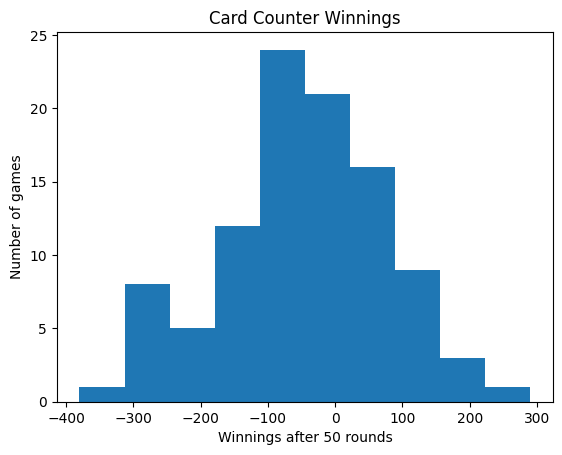

In [8]:
# At first I created a Card class, then the Deck class, and finally the Player class.
# The card class stores the suit and rank of the cards that are in play
# Then the deck class makes a deck with multiple decks and adds an end card at a random point within the large deck, then draws the cards.
# The player class then stores chips and keeps the players hand - Keeping track of the players hand value and letting the player choose
# if he wants an Ace he potentially has to be a 1 or an 11.
# Then I make a dealer class, which hides one of the cards in play, and lists his current card shown on the table.
# After that I make a game class to start a round, take a bet, deal the cards & show the table to the house and the player, 
# And allow the player to hit or stand; And at the end of the round, the game compares the players' and dealers total, and finds a winner.
import matplotlib.pyplot as plt
import statistics
import random


class Card:
    suits = ["Hearts", "Clubs", "Diamonds", "Spades"]
    ranks = ["Ace", "2", "3", "4", "5", "6", "7", "8", "9", "10", "Jack", "Queen", "King"]

    def __init__(self, suit, rank): # Making the cards & labeling which card it is
        self.suit_name = suit
        self.rank_name = rank
        self.endcard = False # Assigning this as false so not all nromal cards are set as end cards.

    def rank(self):
        return self.rank_name

    def card_value(self): # Setting a value to all cards.
        if self.rank_name == "Ace": # This I set for later when the dealer/player comes into play.
            value = 0
        elif self.rank_name == "Jack" or self.rank_name == "Queen" or self.rank_name == "King":
            value = 10
        else:
            value = int(self.rank_name)

        return value

    def set_endcard(self):
        self.endcard = True

    def is_endcard(self):
        return self.endcard

    def __str__(self): # Looking to see if it's the end card or normal card, and printing it.
        if self.endcard == True:
            which_card = "End Card"
        else:
            which_card = str(self.rank_name) + " of " + str(self.suit_name)

        return which_card


class Deck:
    def __init__(self, num_of_decks = 6): # Making the deck & Assigning 6 decks.
        self.num_of_decks = num_of_decks
        self.cards = []
        self.shuffle_next_hand = False
        self.make_new_deck()

    def make_new_deck(self): # Builds the deck then adds the end card and reshuffles.
        self.cards = []

        for i in range(self.num_of_decks):
            for suit in Card.suits:
                for rank in Card.ranks:
                    self.cards.append(Card(suit, rank))

        endcard = Card("Card", "Plastic")
        endcard.set_endcard()

        place = random.randint(0, len(self.cards) - 1) # Choosing a random spot for the end card.
        self.cards.insert(place, endcard)

        random.shuffle(self.cards)
        self.shuffle_next_hand = False

    def draw_card(self):
        if len(self.cards) == 0:
            self.make_new_deck() # If the deck is empty this will make a new deck

        card = self.cards.pop()

        if card.is_endcard() == True:
            self.shuffle_next_hand = True

            if len(self.cards) == 0:
                self.make_new_deck()

            card = self.cards.pop()

        return card

    def shuffle_if_needed(self):
        if self.shuffle_next_hand == True:
            self.make_new_deck()


class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        self.cards.append(card)

    def clear_hand(self):
        self.cards = []

    def show_hand(self):
        for card in self.cards:
            print(card)

    def hand_value(self, player_choice = False):
        total = 0
        ace_count = 0
    
        for card in self.cards:
            if card.rank() == "Ace":
                ace_count = ace_count + 1
            else:
                total = total + card.card_value()
    
        for i in range(ace_count):
            if player_choice == True and total + 11 <= 21:
                choice = ""
    
                while choice != "1" and choice != "11":
                    choice = input("Since you have an Ace and you would not bust by choosing 11, Would you want the Ace to be a 1 or an 11? Pick 1 or 11.")
    
                    if choice != "1" and choice != "11":
                        print("Please choose 1 or 11.")
    
                if choice == "11":
                    total = total + 11
                else:
                    total = total + 1
    
            else:
                total = total + 11
    
        while total > 21 and ace_count > 0:
            total = total - 10
            ace_count = ace_count - 1
    
        return total

    def is_bust(self):
        if self.hand_value() > 21: # Busting the player if over 21
            busted = True
        else:
            busted = False

        return busted


class Player:
    def __init__(self, chips = 1000): # Assigns the player chips and a hand.
        self.chips_amt = chips
        self.hand = Hand()
        self.current_bet = 0

    def hit(self, deck):
        card = deck.draw_card()
        self.hand.add_card(card)
        return card

    def place_bet(self, amount):
        if amount > self.chips_amt:
            print("You need more chips!")
            self.current_bet = 0
        elif amount <= 0:
            print("Has to be more than 0 and cannot be negative.")
            self.current_bet = 0
        else:
            self.current_bet = amount
            self.last_bet = amount
            self.chips_amt = self.chips_amt - amount

    def win_bet(self):
        self.chips_amt = self.chips_amt + self.current_bet * 2 # After the player wins, gives them their winnings, then clears the bet.
        self.current_bet = 0

    def lose_bet(self): # Player loses their bet.
        self.current_bet = 0

    def give_bet_back(self): # If the player ties the dealer, it returns their bet back to them, then clears their bet.
        self.chips_amt = self.chips_amt + self.current_bet
        self.current_bet = 0

class CardCounter(Player):
    def __init__(self, chips = 1000, advantage = 0):
        super().__init__(chips)
        self.current_advantage = advantage
        self.count = 0

    def card_count_total(self, card): # Gives each card it's count value
        if card.rank() == "2" or card.rank() == "3" or card.rank() == "4" or card.rank() == "5" or card.rank() == "6":
            value = 1
        elif card.rank() == "7" or card.rank() == "8" or card.rank() == "9":
            value = 0
        else:
            value = -1

        return value

    def update_count(self, shown_cards):
        self.count = 0 # Restarts the count when new session, and counts each one seen.

        for card in shown_cards:
            self.count = self.count + self.card_count_total(card)

    def make_advantaged_move(self, shown_cards):
        self.update_count(shown_cards)
    
        total = self.hand.hand_value(False)
    
        if total < 12:
            advantage_move = "hit"
        elif total >= 17:
            advantage_move = "stand"
        else:
            if self.count >= self.current_advantage:
                advantage_move = "stand" # High count makes the player stand
            else:
                advantage_move = "hit" # Low count makes the player hit
    
        return advantage_move

    def make_bet_amount(self):
        if self.count >= 10:
            bet = 50
        elif self.count >= 5:
            bet = 25
        else:
            bet = 10
    
        if bet > self.chips_amt:
            bet = self.chips_amt
    
        return bet

class OtherPlayers(Player): # Adds in the other players similar to the dealer.
    def make_move(self):
        total = self.hand.hand_value(False)

        if total < 17:
            move = "hit"
        else:
            move = "stand"

        return move

class Dealer:
    def __init__(self): # Gives the dealer a hand.
        self.hand = Hand()

    def hit(self, deck):
        card = deck.draw_card()
        self.hand.add_card(card)
        return card

    def show_dealer_start_hand(self):
        print(self.hand.cards[0])
        print("Hidden Card")

    def house_turn(self, deck):
        new_cards = []
    
        while self.hand.hand_value() < 17: # Makes sure the dealer hits on 16 and stops on 17.
            card = self.hit(deck)
            new_cards.append(card) # Shows the dealer card.
    
        return new_cards


class Game:
    def __init__(self, num_of_decks = 6, quiet = True):
        self.deck = Deck(num_of_decks)
        self.card_counter = CardCounter(1000, 0)
        self.players = [self.card_counter, OtherPlayers(1000), OtherPlayers(1000), OtherPlayers(1000)]
        self.dealer = Dealer()
        self.shown_cards = []
        self.all_seen_cards = []
        self.game_state = "Waiting for a player"
        self.quiet = quiet
        self.last_bet = 0

    def add_shown_card(self, card):
        self.shown_cards.append(card)
        self.all_seen_cards.append(card) # Lets the card counter remember cards across the game.

    def show_shown_cards(self):
        print("Cards shown so far: ")

        for card in self.shown_cards:
            print(card)

    def start_round(self):
        if self.deck.shuffle_next_hand == True:
            self.deck.shuffle_if_needed()
            self.all_seen_cards = [] # If the deck gets shuffled the count resets
    
        for player in self.players:
            player.hand.clear_hand()
    
        self.dealer.hand.clear_hand()
        self.shown_cards = []
        self.game_state = "Game started"

    def take_bets(self):
        self.game_state = "Betting Phase"

        print(f"You have {self.player.chips_amt} chips left.")
        amount = int(input("How many chips would you like to bet? "))

        self.player.place_bet(amount)

    def test_bets(self):
        self.card_counter.update_count(self.all_seen_cards)
    
        card_counter_bet = self.card_counter.make_bet_amount()
        self.card_counter.place_bet(card_counter_bet)
    
        for player in self.players[1:]:
            if player.chips_amt >= 100:
                player.place_bet(100)

    def deal_cards(self):
        self.game_state = "Cards in play"
    
        for i in range(2):
            for player in self.players:
                card = player.hit(self.deck)
                self.add_shown_card(card)
    
            card = self.dealer.hit(self.deck)
            self.add_shown_card(card)

    def card_counter_turn(self):
        player_total = self.card_counter.hand.hand_value(False)
    
        while player_total <= 21 and self.card_counter.make_advantaged_move(self.all_seen_cards) == "hit":
            card = self.card_counter.hit(self.deck)
            self.add_shown_card(card)
    
            player_total = self.card_counter.hand.hand_value(False)
    
        self.card_counter.update_count(self.all_seen_cards)
    
        return player_total

    def other_players_turn(self, player):
        player_total = player.hand.hand_value(False)
    
        while player_total < 17:
            card = player.hit(self.deck)
            self.add_shown_card(card)
    
            player_total = player.hand.hand_value(False)
    
        return player_total

    def current_table(self):
        print("\nThis is the player's hand.")
        self.player.hand.show_hand()

        print("\nThis is the dealers hand.")
        self.dealer.show_dealer_start_hand()

        print()
        self.show_shown_cards()

    def player_turn(self):
        self.game_state = "Player Turn"

        print("\nIt is the player's turn.")
        player_turn = True
        total = 0

        while player_turn == True:
            print("\nThis is your hand:")
            self.player.hand.show_hand()

            total = self.player.hand.hand_value(True)
            print(f"Your hands total is: {total}\n")

            if total > 21:
                print("You bust!")
                player_turn = False
            else:
                choice = input("Would you like to hit or stand?")
                choice = choice.lower()

                if choice == "hit":
                    card = self.player.hit(self.deck)
                    self.add_shown_card(card)
                elif choice == "stand":
                    player_turn = False
                else:
                    print("Choose Hit or Stand.")

        return total

    def dealers_turn(self):
        self.game_state = "Dealers Turn"
    
        dealer_cards = self.dealer.house_turn(self.deck) 
    
        for card in dealer_cards:
            self.add_shown_card(card)

    def find_winner(self, player_totals):
        self.game_state = "Game over"
    
        dealer_total = self.dealer.hand.hand_value()
        results = []
    
        for i in range(len(self.players)):
            player = self.players[i]
            player_total = player_totals[i]
    
            if i == 0:
                player_name = "Card Counter"
            else:
                player_name = "Player " + str(i + 1)
    
            if player_total > 21:
                player.lose_bet()
                results.append(f"{player_name} busted and lost.")
            elif dealer_total > 21:
                player.win_bet()
                results.append(f"{player_name} won because dealer busted.")
            elif player_total > dealer_total:
                player.win_bet()
                results.append(f"{player_name} won.")
            elif player_total < dealer_total:
                player.lose_bet()
                results.append(f"{player_name} lost.")
            else:
                player.give_bet_back()
                results.append(f"{player_name} tied, so the bet was returned.")
    
        return results

    def play_round(self): # Plays out the round.
        in_game = True

        while in_game == True:
            self.start_round()
            self.take_bets()
            self.deal_cards()
            self.current_table()

            player_total = self.player_turn()

            if player_total <= 21:
                self.dealers_turn()

            self.find_winner(player_total)

            choice = input("\nPlay again? (y/n) ")
            choice = choice.lower()

            if choice == "y":
                in_game = True
            elif choice == "n":
                in_game = False

    def test_player_turn(self):
        player_total = self.player.hand.hand_value(False) # AI Chooses the ace value
    
        while player_total <= 21 and self.player.make_advantaged_move(self.all_seen_cards) == "hit": # If advantage is high, hit.
            print(f"Current card count is: {self.player.count}") 
            print("Card counter chooses to hit.")
    
            card = self.player.hit(self.deck)
            self.add_shown_card(card)
    
            print(f"Player hits and gets a {card}")
    
            player_total = self.player.hand.hand_value(False)
            print(f"Player total is now: {player_total}\n")
    
        if player_total <= 21:
            self.player.update_count(self.all_seen_cards) 
            print(f"Current card count is: {self.player.count}")
            print("Card counter chooses to stand.")
    
        if player_total > 21:
            print("Player loses! - They bust!")
    
        return player_total
    
    def test_round(self):
        self.start_round()
        self.test_bets()
        self.deal_cards()

        player_totals = []

        card_counter_total = self.card_counter_turn()
        player_totals.append(card_counter_total)

        for num in range(1, len(self.players)):
            total = self.other_players_turn(self.players[num])
            player_totals.append(total)

        self.dealers_turn()

        results = self.find_winner(player_totals)

        return results

profits = []

for game_number in range(100):
    game = Game(6, True)
    starting_chips = game.card_counter.chips_amt

    for round_number in range(50):
        if game.card_counter.chips_amt > 0:
            game.test_round()

    ending_chips = game.card_counter.chips_amt
    profits.append(ending_chips - starting_chips)

average_winnings = statistics.mean(profits)
standard_deviation = statistics.stdev(profits)

wins = 0
losses = 0

for amount in profits:
    if amount > 0:
        wins = wins + 1
    elif amount < 0:
        losses = losses + 1

print("Winnings: ")
print(profits)

print(f"\nAverage winnings after 50 rounds: {average_winnings}")
print(f"Average winnings per round: {average_winnings / 50}")
print(f"Standard deviation of the 50 rounds: {standard_deviation}")

print(f"\nProbability of winning after 50 rounds: {wins / 100}")
print(f"Probability of losing after 50 rounds: {losses / 100}")

plt.hist(profits)
plt.xlabel("Winnings after 50 rounds")
plt.ylabel("Number of games")
plt.title("Card Counter Winnings")
plt.show()

In [ ]:
What is the average winnings per round?
The average winnings per round is -0.98, and -49 after 50 rounds.

The standard deviation is 126.1512640211798 after 50 rounds.

The probability of winning after 50 rounds is 0.34

Compared to losing at 0.66.

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?


Threshold: -10
Average winnings after 50 rounds: -71.95
Average winnings per round: -1.439
Standard deviation: 109.27884590173966
Probability of winning after 50 rounds: 0.18
Probability of losing after 50 rounds: 0.8

Threshold: -4
Average winnings after 50 rounds: -83.95
Average winnings per round: -1.679
Standard deviation: 133.2675879574625
Probability of winning after 50 rounds: 0.22
Probability of losing after 50 rounds: 0.76

Threshold: 2
Average winnings after 50 rounds: -53.6
Average winnings per round: -1.072
Standard deviation: 103.5703050145556
Probability of winning after 50 rounds: 0.26
Probability of losing after 50 rounds: 0.73

Threshold: 8
Average winnings after 50 rounds: -48.3
Average winnings per round: -0.966
Standard deviation: 117.16391867116701
Probability of winning after 50 rounds: 0.33
Probability of losing after 50 rounds: 0.67

Threshold: 12
Average winnings after 50 rounds: -72.1
Average winnings per round: -1.442
Standard deviation: 121.44371436009259
P

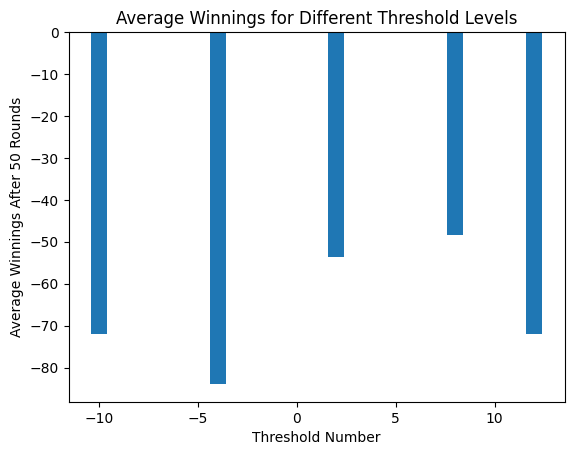

In [11]:
# At first I created a Card class, then the Deck class, and finally the Player class.
# The card class stores the suit and rank of the cards that are in play
# Then the deck class makes a deck with multiple decks and adds an end card at a random point within the large deck, then draws the cards.
# The player class then stores chips and keeps the players hand - Keeping track of the players hand value and letting the player choose
# if he wants an Ace he potentially has to be a 1 or an 11.
# Then I make a dealer class, which hides one of the cards in play, and lists his current card shown on the table.
# After that I make a game class to start a round, take a bet, deal the cards & show the table to the house and the player, 
# And allow the player to hit or stand; And at the end of the round, the game compares the players' and dealers total, and finds a winner.
import matplotlib.pyplot as plt
import statistics
import random


class Card:
    suits = ["Hearts", "Clubs", "Diamonds", "Spades"]
    ranks = ["Ace", "2", "3", "4", "5", "6", "7", "8", "9", "10", "Jack", "Queen", "King"]

    def __init__(self, suit, rank): # Making the cards & labeling which card it is
        self.suit_name = suit
        self.rank_name = rank
        self.endcard = False # Assigning this as false so not all nromal cards are set as end cards.

    def rank(self):
        return self.rank_name

    def card_value(self): # Setting a value to all cards.
        if self.rank_name == "Ace": # This I set for later when the dealer/player comes into play.
            value = 0
        elif self.rank_name == "Jack" or self.rank_name == "Queen" or self.rank_name == "King":
            value = 10
        else:
            value = int(self.rank_name)

        return value

    def set_endcard(self):
        self.endcard = True

    def is_endcard(self):
        return self.endcard

    def __str__(self): # Looking to see if it's the end card or normal card, and printing it.
        if self.endcard == True:
            which_card = "End Card"
        else:
            which_card = str(self.rank_name) + " of " + str(self.suit_name)

        return which_card


class Deck:
    def __init__(self, num_of_decks = 6): # Making the deck & Assigning 6 decks.
        self.num_of_decks = num_of_decks
        self.cards = []
        self.shuffle_next_hand = False
        self.make_new_deck()

    def make_new_deck(self): # Builds the deck then adds the end card and reshuffles.
        self.cards = []

        for i in range(self.num_of_decks):
            for suit in Card.suits:
                for rank in Card.ranks:
                    self.cards.append(Card(suit, rank))

        endcard = Card("Card", "Plastic")
        endcard.set_endcard()

        place = random.randint(0, len(self.cards) - 1) # Choosing a random spot for the end card.
        self.cards.insert(place, endcard)

        random.shuffle(self.cards)
        self.shuffle_next_hand = False

    def draw_card(self):
        if len(self.cards) == 0:
            self.make_new_deck() # If the deck is empty this will make a new deck

        card = self.cards.pop()

        if card.is_endcard() == True:
            self.shuffle_next_hand = True

            if len(self.cards) == 0:
                self.make_new_deck()

            card = self.cards.pop()

        return card

    def shuffle_if_needed(self):
        if self.shuffle_next_hand == True:
            self.make_new_deck()


class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        self.cards.append(card)

    def clear_hand(self):
        self.cards = []

    def show_hand(self):
        for card in self.cards:
            print(card)

    def hand_value(self, player_choice = False):
        total = 0
        ace_count = 0
    
        for card in self.cards:
            if card.rank() == "Ace":
                ace_count = ace_count + 1
            else:
                total = total + card.card_value()
    
        for i in range(ace_count):
            if player_choice == True and total + 11 <= 21:
                choice = ""
    
                while choice != "1" and choice != "11":
                    choice = input("Since you have an Ace and you would not bust by choosing 11, Would you want the Ace to be a 1 or an 11? Pick 1 or 11.")
    
                    if choice != "1" and choice != "11":
                        print("Please choose 1 or 11.")
    
                if choice == "11":
                    total = total + 11
                else:
                    total = total + 1
    
            else:
                total = total + 11
    
        while total > 21 and ace_count > 0:
            total = total - 10
            ace_count = ace_count - 1
    
        return total

    def is_bust(self):
        if self.hand_value() > 21: # Busting the player if over 21
            busted = True
        else:
            busted = False

        return busted


class Player:
    def __init__(self, chips = 1000): # Assigns the player chips and a hand.
        self.chips_amt = chips
        self.hand = Hand()
        self.current_bet = 0

    def hit(self, deck):
        card = deck.draw_card()
        self.hand.add_card(card)
        return card

    def place_bet(self, amount):
        if amount > self.chips_amt:
            print("You need more chips!")
            self.current_bet = 0
        elif amount <= 0:
            print("Has to be more than 0 and cannot be negative.")
            self.current_bet = 0
        else:
            self.current_bet = amount
            self.last_bet = amount
            self.chips_amt = self.chips_amt - amount

    def win_bet(self):
        self.chips_amt = self.chips_amt + self.current_bet * 2 # After the player wins, gives them their winnings, then clears the bet.
        self.current_bet = 0

    def lose_bet(self): # Player loses their bet.
        self.current_bet = 0

    def give_bet_back(self): # If the player ties the dealer, it returns their bet back to them, then clears their bet.
        self.chips_amt = self.chips_amt + self.current_bet
        self.current_bet = 0

class CardCounter(Player):
    def __init__(self, chips = 1000, advantage = 0):
        super().__init__(chips)
        self.current_advantage = advantage
        self.count = 0

    def card_count_total(self, card): # Gives each card it's count value
        if card.rank() == "2" or card.rank() == "3" or card.rank() == "4" or card.rank() == "5" or card.rank() == "6":
            value = 1
        elif card.rank() == "7" or card.rank() == "8" or card.rank() == "9":
            value = 0
        else:
            value = -1

        return value

    def update_count(self, shown_cards):
        self.count = 0 # Restarts the count when new session, and counts each one seen.

        for card in shown_cards:
            self.count = self.count + self.card_count_total(card)

    def make_advantaged_move(self, shown_cards):
        self.update_count(shown_cards)
    
        total = self.hand.hand_value(False)
    
        if total < 12:
            advantage_move = "hit"
        elif total >= 17:
            advantage_move = "stand"
        else:
            if self.count >= self.current_advantage:
                advantage_move = "stand" # High count makes the player stand
            else:
                advantage_move = "hit" # Low count makes the player hit
    
        return advantage_move

    def make_bet_amount(self):
        if self.count >= 10:
            bet = 50
        elif self.count >= 5:
            bet = 25
        else:
            bet = 10
    
        if bet > self.chips_amt:
            bet = self.chips_amt
    
        return bet

class OtherPlayers(Player): # Adds in the other players similar to the dealer.
    def make_move(self):
        total = self.hand.hand_value(False)

        if total < 17:
            move = "hit"
        else:
            move = "stand"

        return move

class Dealer:
    def __init__(self): # Gives the dealer a hand.
        self.hand = Hand()

    def hit(self, deck):
        card = deck.draw_card()
        self.hand.add_card(card)
        return card

    def show_dealer_start_hand(self):
        print(self.hand.cards[0])
        print("Hidden Card")

    def house_turn(self, deck):
        new_cards = []
    
        while self.hand.hand_value() < 17: # Makes sure the dealer hits on 16 and stops on 17.
            card = self.hit(deck)
            new_cards.append(card) # Shows the dealer card.
    
        return new_cards


class Game:
    def __init__(self, num_of_decks = 6, quiet = True, threshold = 0):
        self.deck = Deck(num_of_decks)
        self.card_counter = CardCounter(1000, threshold)
        self.players = [self.card_counter, OtherPlayers(1000), OtherPlayers(1000), OtherPlayers(1000)]
        self.dealer = Dealer()
        self.shown_cards = []
        self.all_seen_cards = []
        self.game_state = "Waiting for a player"
        self.quiet = quiet
        self.last_bet = 0

    def add_shown_card(self, card):
        self.shown_cards.append(card)
        self.all_seen_cards.append(card) # Lets the card counter remember cards across the game.

    def show_shown_cards(self):
        print("Cards shown so far: ")

        for card in self.shown_cards:
            print(card)

    def start_round(self):
        if self.deck.shuffle_next_hand == True:
            self.deck.shuffle_if_needed()
            self.all_seen_cards = [] # If the deck gets shuffled the count resets
    
        for player in self.players:
            player.hand.clear_hand()
    
        self.dealer.hand.clear_hand()
        self.shown_cards = []
        self.game_state = "Game started"

    def take_bets(self):
        self.game_state = "Betting Phase"

        print(f"You have {self.player.chips_amt} chips left.")
        amount = int(input("How many chips would you like to bet? "))

        self.player.place_bet(amount)

    def test_bets(self):
        self.card_counter.update_count(self.all_seen_cards)
    
        card_counter_bet = self.card_counter.make_bet_amount()
        self.card_counter.place_bet(card_counter_bet)
    
        for player in self.players[1:]:
            if player.chips_amt >= 100:
                player.place_bet(100)

    def deal_cards(self):
        self.game_state = "Cards in play"
    
        for i in range(2):
            for player in self.players:
                card = player.hit(self.deck)
                self.add_shown_card(card)
    
            card = self.dealer.hit(self.deck)
            self.add_shown_card(card)

    def card_counter_turn(self):
        player_total = self.card_counter.hand.hand_value(False)
    
        while player_total <= 21 and self.card_counter.make_advantaged_move(self.all_seen_cards) == "hit":
            card = self.card_counter.hit(self.deck)
            self.add_shown_card(card)
    
            player_total = self.card_counter.hand.hand_value(False)
    
        self.card_counter.update_count(self.all_seen_cards)
    
        return player_total

    def other_players_turn(self, player):
        player_total = player.hand.hand_value(False)
    
        while player_total < 17:
            card = player.hit(self.deck)
            self.add_shown_card(card)
    
            player_total = player.hand.hand_value(False)
    
        return player_total

    def current_table(self):
        print("\nThis is the player's hand.")
        self.player.hand.show_hand()

        print("\nThis is the dealers hand.")
        self.dealer.show_dealer_start_hand()

        print()
        self.show_shown_cards()

    def player_turn(self):
        self.game_state = "Player Turn"

        print("\nIt is the player's turn.")
        player_turn = True
        total = 0

        while player_turn == True:
            print("\nThis is your hand:")
            self.player.hand.show_hand()

            total = self.player.hand.hand_value(True)
            print(f"Your hands total is: {total}\n")

            if total > 21:
                print("You bust!")
                player_turn = False
            else:
                choice = input("Would you like to hit or stand?")
                choice = choice.lower()

                if choice == "hit":
                    card = self.player.hit(self.deck)
                    self.add_shown_card(card)
                elif choice == "stand":
                    player_turn = False
                else:
                    print("Choose Hit or Stand.")

        return total

    def dealers_turn(self):
        self.game_state = "Dealers Turn"
    
        dealer_cards = self.dealer.house_turn(self.deck) 
    
        for card in dealer_cards:
            self.add_shown_card(card)

    def find_winner(self, player_totals):
        self.game_state = "Game over"
    
        dealer_total = self.dealer.hand.hand_value()
        results = []
    
        for i in range(len(self.players)):
            player = self.players[i]
            player_total = player_totals[i]
    
            if i == 0:
                player_name = "Card Counter"
            else:
                player_name = "Player " + str(i + 1)
    
            if player_total > 21:
                player.lose_bet()
                results.append(f"{player_name} busted and lost.")
            elif dealer_total > 21:
                player.win_bet()
                results.append(f"{player_name} won because dealer busted.")
            elif player_total > dealer_total:
                player.win_bet()
                results.append(f"{player_name} won.")
            elif player_total < dealer_total:
                player.lose_bet()
                results.append(f"{player_name} lost.")
            else:
                player.give_bet_back()
                results.append(f"{player_name} tied, so the bet was returned.")
    
        return results

    def play_round(self): # Plays out the round.
        in_game = True

        while in_game == True:
            self.start_round()
            self.take_bets()
            self.deal_cards()
            self.current_table()

            player_total = self.player_turn()

            if player_total <= 21:
                self.dealers_turn()

            self.find_winner(player_total)

            choice = input("\nPlay again? (y/n) ")
            choice = choice.lower()

            if choice == "y":
                in_game = True
            elif choice == "n":
                in_game = False

    def test_player_turn(self):
        player_total = self.player.hand.hand_value(False) # AI Chooses the ace value
    
        while player_total <= 21 and self.player.make_advantaged_move(self.all_seen_cards) == "hit": # If advantage is high, hit.
            print(f"Current card count is: {self.player.count}") 
            print("Card counter chooses to hit.")
    
            card = self.player.hit(self.deck)
            self.add_shown_card(card)
    
            print(f"Player hits and gets a {card}")
    
            player_total = self.player.hand.hand_value(False)
            print(f"Player total is now: {player_total}\n")
    
        if player_total <= 21:
            self.player.update_count(self.all_seen_cards) 
            print(f"Current card count is: {self.player.count}")
            print("Card counter chooses to stand.")
    
        if player_total > 21:
            print("Player loses! - They bust!")
    
        return player_total
    
    def test_round(self):
        self.start_round()
        self.test_bets()
        self.deal_cards()

        player_totals = []

        card_counter_total = self.card_counter_turn()
        player_totals.append(card_counter_total)

        for num in range(1, len(self.players)):
            total = self.other_players_turn(self.players[num])
            player_totals.append(total)

        self.dealers_turn()

        results = self.find_winner(player_totals)

        return results

thresholds = [-10, -4, 2, 8, 12]
average_results = []

for threshold in thresholds:
    profits = []

    for game_number in range(100):
        game = Game(6, True, threshold)
        starting_chips = game.card_counter.chips_amt

        for round_number in range(50):
            if game.card_counter.chips_amt <= 0:
                break

            game.test_round()

        ending_chips = game.card_counter.chips_amt
        profits.append(ending_chips - starting_chips)

    average_winnings = statistics.mean(profits)
    standard_deviation = statistics.stdev(profits)

    wins = 0
    losses = 0

    for amount in profits:
        if amount > 0:
            wins = wins + 1
        elif amount < 0:
            losses = losses + 1

    average_results.append(average_winnings)

    print("\nThreshold:", threshold)
    print("Average winnings after 50 rounds:", average_winnings)
    print("Average winnings per round:", average_winnings / 50)
    print("Standard deviation:", standard_deviation)
    print("Probability of winning after 50 rounds:", wins / 100)
    print("Probability of losing after 50 rounds:", losses / 100)

plt.bar(thresholds, average_results)
plt.xlabel("Threshold Number")
plt.ylabel("Average Winnings After 50 Rounds")
plt.title("Average Winnings for Different Threshold Levels")
plt.show()

In [ ]:
It looks like the best chance of winning is at the threshold of 8 if we're looking at the average winnings and the probability of winning after 50 rounds, with a close runner up at 2.

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [ ]:
I thought about only betting high when the card count is above 10. next to nothing when it is -4.

New strategy results:
[46, 446, -132, 53, -230, 56, -69, 35, -235, -43, -252, 142, -102, -70, -32, -90, 4, 9, -329, 93, -23, 72, -13, -242, -76, -30, -91, -261, -354, -140, -33, 147, -48, -24, -2, 158, -80, 41, -97, -241, -530, -95, -67, 270, -45, -215, -1, -23, -153, -184, -89, 39, -74, -1, -146, 59, -152, -368, -24, 181, -89, 10, 49, -160, -324, -141, 35, 4, 251, 41, -80, -92, -205, 10, -30, -211, 47, -96, -12, -12, -2, 192, 60, -361, 8, 14, -47, -282, -207, 45, -22, -106, -34, -122, 123, -166, -14, -185, -5, -85]

Average winnings after 50 rounds: -58.56
Average winnings per round: -1.1712
Standard deviation: 145.52970608619862

Probability of winning after 50 rounds: 0.31
Probability of losing after 50 rounds: 0.69


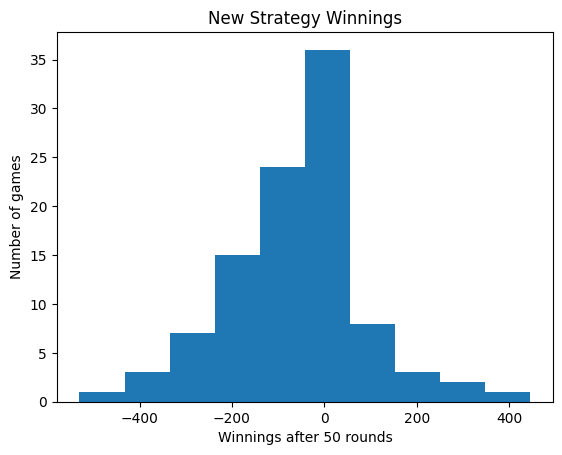

In [12]:
# At first I created a Card class, then the Deck class, and finally the Player class.
# The card class stores the suit and rank of the cards that are in play
# Then the deck class makes a deck with multiple decks and adds an end card at a random point within the large deck, then draws the cards.
# The player class then stores chips and keeps the players hand - Keeping track of the players hand value and letting the player choose
# if he wants an Ace he potentially has to be a 1 or an 11.
# Then I make a dealer class, which hides one of the cards in play, and lists his current card shown on the table.
# After that I make a game class to start a round, take a bet, deal the cards & show the table to the house and the player, 
# And allow the player to hit or stand; And at the end of the round, the game compares the players' and dealers total, and finds a winner.
import matplotlib.pyplot as plt
import statistics
import random


class Card:
    suits = ["Hearts", "Clubs", "Diamonds", "Spades"]
    ranks = ["Ace", "2", "3", "4", "5", "6", "7", "8", "9", "10", "Jack", "Queen", "King"]

    def __init__(self, suit, rank): # Making the cards & labeling which card it is
        self.suit_name = suit
        self.rank_name = rank
        self.endcard = False # Assigning this as false so not all nromal cards are set as end cards.

    def rank(self):
        return self.rank_name

    def card_value(self): # Setting a value to all cards.
        if self.rank_name == "Ace": # This I set for later when the dealer/player comes into play.
            value = 0
        elif self.rank_name == "Jack" or self.rank_name == "Queen" or self.rank_name == "King":
            value = 10
        else:
            value = int(self.rank_name)

        return value

    def set_endcard(self):
        self.endcard = True

    def is_endcard(self):
        return self.endcard

    def __str__(self): # Looking to see if it's the end card or normal card, and also printing the end card.
        if self.endcard == True:
            which_card = "End Card"
        else:
            which_card = str(self.rank_name) + " of " + str(self.suit_name)

        return which_card


class Deck:
    def __init__(self, num_of_decks = 6): # Making the deck & Assigning 6 decks.
        self.num_of_decks = num_of_decks
        self.cards = []
        self.shuffle_next_hand = False
        self.make_new_deck()

    def make_new_deck(self): # Builds the deck then adds the end card and reshuffles.
        self.cards = []

        for i in range(self.num_of_decks):
            for suit in Card.suits:
                for rank in Card.ranks:
                    self.cards.append(Card(suit, rank))

        endcard = Card("Card", "Plastic")
        endcard.set_endcard()

        place = random.randint(0, len(self.cards) - 1) # Choosing a random spot for the end card.
        self.cards.insert(place, endcard)

        random.shuffle(self.cards)
        self.shuffle_next_hand = False

    def draw_card(self):
        if len(self.cards) == 0:
            self.make_new_deck() # If the deck is empty this will make a new deck

        card = self.cards.pop()

        if card.is_endcard() == True:
            self.shuffle_next_hand = True

            if len(self.cards) == 0:
                self.make_new_deck()

            card = self.cards.pop()

        return card

    def shuffle_if_needed(self):
        if self.shuffle_next_hand == True:
            self.make_new_deck()


class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        self.cards.append(card)

    def clear_hand(self):
        self.cards = []

    def show_hand(self):
        for card in self.cards:
            print(card)

    def hand_value(self, player_choice = False):
        total = 0
        ace_count = 0
    
        for card in self.cards:
            if card.rank() == "Ace":
                ace_count = ace_count + 1 # Aces get counted after the other cards since the value can change
            else:
                total = total + card.card_value()
    
        for i in range(ace_count):
            if player_choice == True and total + 11 <= 21: # Player chooses ace value if it wont bust the hand
                choice = ""
    
                while choice != "1" and choice != "11":
                    choice = input("Since you have an Ace and you would not bust by choosing 11, Would you want the Ace to be a 1 or an 11? Pick 1 or 11.")
    
                    if choice != "1" and choice != "11":
                        print("Please choose 1 or 11.")
    
                if choice == "11":
                    total = total + 11
                else:
                    total = total + 1
    
            else:
                total = total + 11
    
        while total > 21 and ace_count > 0:
            total = total - 10
            ace_count = ace_count - 1
    
        return total

    def is_bust(self):
        if self.hand_value() > 21: # Busting the player if over 21 
            busted = True
        else:
            busted = False

        return busted


class Player:
    def __init__(self, chips = 1000): # Assigns the player chips and a hand.
        self.chips_amt = chips
        self.hand = Hand()
        self.current_bet = 0

    def hit(self, deck):
        card = deck.draw_card()
        self.hand.add_card(card)
        return card

    def place_bet(self, amount):
        if amount > self.chips_amt:
            print("You need more chips!")
            self.current_bet = 0
        elif amount <= 0:
            print("Has to be more than 0 and cannot be negative.")
            self.current_bet = 0
        else:
            self.current_bet = amount
            self.last_bet = amount
            self.chips_amt = self.chips_amt - amount

    def win_bet(self):
        self.chips_amt = self.chips_amt + self.current_bet * 2 # After the player wins, gives them their winnings, then clears the bet.
        self.current_bet = 0

    def lose_bet(self): # Player loses their bet.
        self.current_bet = 0

    def give_bet_back(self): # If the player ties the dealer, it returns their bet back to them, then clears their bet.
        self.chips_amt = self.chips_amt + self.current_bet
        self.current_bet = 0

class CardCounter(Player):
    def __init__(self, chips = 1000, advantage = 0):
        super().__init__(chips)
        self.current_advantage = advantage
        self.count = 0

    def card_count_total(self, card): # Gives each card it's count value
        if card.rank() == "2" or card.rank() == "3" or card.rank() == "4" or card.rank() == "5" or card.rank() == "6":
            value = 1
        elif card.rank() == "7" or card.rank() == "8" or card.rank() == "9":
            value = 0
        else:
            value = -1

        return value

    def update_count(self, shown_cards):
        self.count = 0 # Restarts the count when new session, and counts each one seen.

        for card in shown_cards:
            self.count = self.count + self.card_count_total(card)

    def make_advantaged_move(self, shown_cards):
        self.update_count(shown_cards)
    
        total = self.hand.hand_value(False)
    
        if total < 12:
            advantage_move = "hit"
        elif total >= 17:
            advantage_move = "stand"
        else:
            if self.count >= self.current_advantage:
                advantage_move = "stand" # High count makes the player stand
            else:
                advantage_move = "hit" # Low count makes the player hit
    
        return advantage_move

    def make_bet_amount(self):
        if self.count >= 10:
            bet = 50
        elif self.count >= 5:
            bet = 25
        else:
            bet = 10
    
        if bet > self.chips_amt:
            bet = self.chips_amt
    
        return bet

class OtherPlayers(Player): # Adds in the other players similar to the dealer.
    def make_move(self):
        total = self.hand.hand_value(False)

        if total < 17:
            move = "hit"
        else:
            move = "stand"

        return move

class NewCardCounter(CardCounter):
    def make_bet_amount(self):
        if self.count >= 10:
            bet = 75 # Higher counter to bet more when higher advantage
        elif self.count <= -4: # Bet next to nothing when negative advantage
            bet = 1
        else: # No advantage, just normal play
            bet = 10

        if bet > self.chips_amt:
            bet = self.chips_amt

        return bet

class Dealer:
    def __init__(self): # Gives the dealer a hand.
        self.hand = Hand()

    def hit(self, deck):
        card = deck.draw_card()
        self.hand.add_card(card)
        return card

    def show_dealer_start_hand(self):
        print(self.hand.cards[0])
        print("Hidden Card")

    def house_turn(self, deck):
        new_cards = []
    
        while self.hand.hand_value() < 17: # Makes sure the dealer hits on 16 and stops on 17.
            card = self.hit(deck)
            new_cards.append(card) # Shows the dealer card.
    
        return new_cards


class Game:
    def __init__(self, num_of_decks = 6, quiet = True, threshold = 0):
        self.deck = Deck(num_of_decks)
        self.card_counter = NewCardCounter(1000, threshold)
        self.players = [self.card_counter, OtherPlayers(1000), OtherPlayers(1000), OtherPlayers(1000)]
        self.dealer = Dealer()
        self.shown_cards = []
        self.all_seen_cards = []
        self.game_state = "Waiting for a player"
        self.quiet = quiet
        self.last_bet = 0

    def add_shown_card(self, card):
        self.shown_cards.append(card)
        self.all_seen_cards.append(card) # Lets the card counter remember cards across the game.

    def show_shown_cards(self):
        print("Cards shown so far: ")

        for card in self.shown_cards:
            print(card)

    def start_round(self):
        if self.deck.shuffle_next_hand == True:
            self.deck.shuffle_if_needed()
            self.all_seen_cards = [] # If the deck gets shuffled from the endcard the count resets
    
        for player in self.players:
            player.hand.clear_hand()
    
        self.dealer.hand.clear_hand()
        self.shown_cards = []
        self.game_state = "Game started"

    def take_bets(self):
        self.game_state = "Betting Phase"

        print(f"You have {self.player.chips_amt} chips left.")
        amount = int(input("How many chips would you like to bet? "))

        self.player.place_bet(amount)

    def test_bets(self):
        self.card_counter.update_count(self.all_seen_cards) # Updates the count so the card counter can determine what they want to bet
    
        card_counter_bet = self.card_counter.make_bet_amount()
        self.card_counter.place_bet(card_counter_bet)
    
        for player in self.players[1:]: # Simple bets for other players
            if player.chips_amt >= 100:
                player.place_bet(100)

    def deal_cards(self):
        self.game_state = "Cards in play"
    
        for i in range(2): # deals cards to each player / dealer
            for player in self.players:
                card = player.hit(self.deck)
                self.add_shown_card(card)
    
            card = self.dealer.hit(self.deck)
            self.add_shown_card(card)

    def card_counter_turn(self):
        player_total = self.card_counter.hand.hand_value(False)
    
        while player_total <= 21 and self.card_counter.make_advantaged_move(self.all_seen_cards) == "hit": # Card counter hits when the advantage is good and he hasn't bust.
            card = self.card_counter.hit(self.deck)
            self.add_shown_card(card)
    
            player_total = self.card_counter.hand.hand_value(False)
    
        self.card_counter.update_count(self.all_seen_cards)
    
        return player_total

    def other_players_turn(self, player):
        player_total = player.hand.hand_value(False)
    
        while player_total < 17: # Other players use the same strategy the house does.
            card = player.hit(self.deck)
            self.add_shown_card(card)
    
            player_total = player.hand.hand_value(False)
    
        return player_total

    def current_table(self):
        print("\nThis is the player's hand.")
        self.player.hand.show_hand()

        print("\nThis is the dealers hand.")
        self.dealer.show_dealer_start_hand()

        print()
        self.show_shown_cards()

    def player_turn(self):
        self.game_state = "Player Turn"

        print("\nIt is the player's turn.")
        player_turn = True
        total = 0

        while player_turn == True:
            print("\nThis is your hand:")
            self.player.hand.show_hand()

            total = self.player.hand.hand_value(True)
            print(f"Your hands total is: {total}\n")

            if total > 21:
                print("You bust!")
                player_turn = False
            else:
                choice = input("Would you like to hit or stand?")
                choice = choice.lower()

                if choice == "hit":
                    card = self.player.hit(self.deck)
                    self.add_shown_card(card)
                elif choice == "stand":
                    player_turn = False
                else:
                    print("Choose Hit or Stand.")

        return total

    def dealers_turn(self):
        self.game_state = "Dealers Turn"
    
        dealer_cards = self.dealer.house_turn(self.deck) 
    
        for card in dealer_cards:
            self.add_shown_card(card)

    def find_winner(self, player_totals):
        self.game_state = "Game over"
    
        dealer_total = self.dealer.hand.hand_value()
        results = []
    
        for i in range(len(self.players)):
            player = self.players[i]
            player_total = player_totals[i]
    
            if i == 0:
                player_name = "Card Counter"
            else:
                player_name = "Player " + str(i + 1)
    
            if player_total > 21:
                player.lose_bet()
                results.append(f"{player_name} busted and lost.")
            elif dealer_total > 21:
                player.win_bet()
                results.append(f"{player_name} won because dealer busted.")
            elif player_total > dealer_total:
                player.win_bet()
                results.append(f"{player_name} won.")
            elif player_total < dealer_total:
                player.lose_bet()
                results.append(f"{player_name} lost.")
            else:
                player.give_bet_back()
                results.append(f"{player_name} tied, so the bet was returned.")
    
        return results

    def play_round(self): # Plays out the round.
        in_game = True

        while in_game == True:
            self.start_round()
            self.take_bets()
            self.deal_cards()
            self.current_table()

            player_total = self.player_turn()

            if player_total <= 21:
                self.dealers_turn()

            self.find_winner(player_total)

            choice = input("\nPlay again? (y/n) ")
            choice = choice.lower()

            if choice == "y":
                in_game = True
            elif choice == "n":
                in_game = False

    def test_player_turn(self):
        player_total = self.player.hand.hand_value(False) # AI Chooses the ace value
    
        while player_total <= 21 and self.player.make_advantaged_move(self.all_seen_cards) == "hit": # If advantage is high, hit.
            print(f"Current card count is: {self.player.count}") 
            print("Card counter chooses to hit.")
    
            card = self.player.hit(self.deck)
            self.add_shown_card(card)
    
            print(f"Player hits and gets a {card}")
    
            player_total = self.player.hand.hand_value(False)
            print(f"Player total is now: {player_total}\n")
    
        if player_total <= 21:
            self.player.update_count(self.all_seen_cards) 
            print(f"Current card count is: {self.player.count}")
            print("Card counter chooses to stand.")
    
        if player_total > 21:
            print("Player loses! - They bust!")
    
        return player_total
    
    def test_round(self):
        self.start_round()
        self.test_bets()
        self.deal_cards()

        player_totals = []

        card_counter_total = self.card_counter_turn()
        player_totals.append(card_counter_total)

        for num in range(1, len(self.players)):
            total = self.other_players_turn(self.players[num])
            player_totals.append(total)

        self.dealers_turn()

        results = self.find_winner(player_totals)

        return results

profits = []

for game_number in range(100):
    game = Game(6, True, 8)
    starting_chips = game.card_counter.chips_amt

    for round_number in range(50):
        if game.card_counter.chips_amt <= 0:
            break

        game.test_round()

    ending_chips = game.card_counter.chips_amt
    profits.append(ending_chips - starting_chips)

average_winnings = statistics.mean(profits) # Statistics for avg and stddev
standard_deviation = statistics.stdev(profits)

wins = 0
losses = 0

for amount in profits: # To count how often the strategy won or lost after 50 rounds
    if amount > 0:
        wins = wins + 1
    elif amount < 0:
        losses = losses + 1

print("New strategy results:")
print(profits)

print(f"\nAverage winnings after 50 rounds: {average_winnings}")
print(f"Average winnings per round: {average_winnings / 50}")
print(f"Standard deviation: {standard_deviation}")

print(f"\nProbability of winning after 50 rounds: {wins / 100}")
print(f"Probability of losing after 50 rounds: {losses / 100}")

plt.hist(profits)
plt.xlabel("Winnings after 50 rounds")
plt.ylabel("Number of games")
plt.title("New Strategy Winnings")
plt.show()

In [ ]:
It does not have a better chance of winning, it actually is more likely to have a loss.

In [ ]:
#3 skeleton update below

In [ ]:
import matplotlib.pyplot as plt
import statistics
import random


class Card:
    suits = ["Hearts", "Clubs", "Diamonds", "Spades"]
    ranks = ["Ace", "2", "3", "4", "5", "6", "7", "8", "9", "10", "Jack", "Queen", "King"]

    def __init__(self, suit, rank):
        self.suit_name = suit
        self.rank_name = rank
        self.endcard = False

    def rank(self):
        pass

    def card_value(self):
        pass

    def set_endcard(self):
        pass

    def is_endcard(self):
        pass

    def __str__(self):
        pass


class Deck:
    def __init__(self, num_of_decks = 6):
        self.num_of_decks = num_of_decks
        self.cards = []
        self.shuffle_next_hand = False
        self.make_new_deck()

    def make_new_deck(self):
        pass

    def draw_card(self):
        pass

    def shuffle_if_needed(self):
        pass


class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        pass

    def clear_hand(self):
        pass

    def show_hand(self):
        pass

    def hand_value(self, player_choice = False):
        pass

    def is_bust(self):
        pass


class Player:
    def __init__(self, chips = 1000):
        self.chips_amt = chips
        self.hand = Hand()
        self.current_bet = 0

    def hit(self, deck):
        pass

    def place_bet(self, amount):
        pass

    def win_bet(self):
        pass

    def lose_bet(self):
        pass

    def give_bet_back(self):
        pass


class CardCounter(Player):
    def __init__(self, chips = 1000, advantage = 0):
        super().__init__(chips)
        self.current_advantage = advantage
        self.count = 0

    def card_count_total(self, card):
        pass

    def update_count(self, shown_cards):
        pass

    def make_advantaged_move(self, shown_cards):
        pass

    def make_bet_amount(self):
        pass


class OtherPlayers(Player):
    def make_move(self):
        pass


class NewCardCounter(CardCounter):
    def make_bet_amount(self):
        pass


class Dealer:
    def __init__(self):
        self.hand = Hand()

    def hit(self, deck):
        pass

    def show_dealer_start_hand(self):
        pass

    def house_turn(self, deck):
        pass


class Game:
    def __init__(self, num_of_decks = 6, quiet = True, threshold = 0):
        self.deck = Deck(num_of_decks)
        self.card_counter = NewCardCounter(1000, threshold)
        self.players = [self.card_counter, OtherPlayers(1000), OtherPlayers(1000), OtherPlayers(1000)]
        self.dealer = Dealer()
        self.shown_cards = []
        self.all_seen_cards = []
        self.game_state = "Waiting for a player"
        self.quiet = quiet
        self.last_bet = 0

    def add_shown_card(self, card):
        pass

    def show_shown_cards(self):
        pass

    def start_round(self):
        pass

    def take_bets(self):
        pass

    def test_bets(self):
        pass

    def deal_cards(self):
        pass

    def card_counter_turn(self):
        pass

    def other_players_turn(self, player):
        pass

    def current_table(self):
        pass

    def player_turn(self):
        pass

    def dealers_turn(self):
        pass

    def find_winner(self, player_totals):
        pass

    def play_round(self):
        pass

    def test_player_turn(self):
        pass

    def test_round(self):
        pass